# Модель поведенческого скоринга клиентов банка «Ва-банк»

- Автор: Евдокимов Александр
- Дата: 26.09.26

---

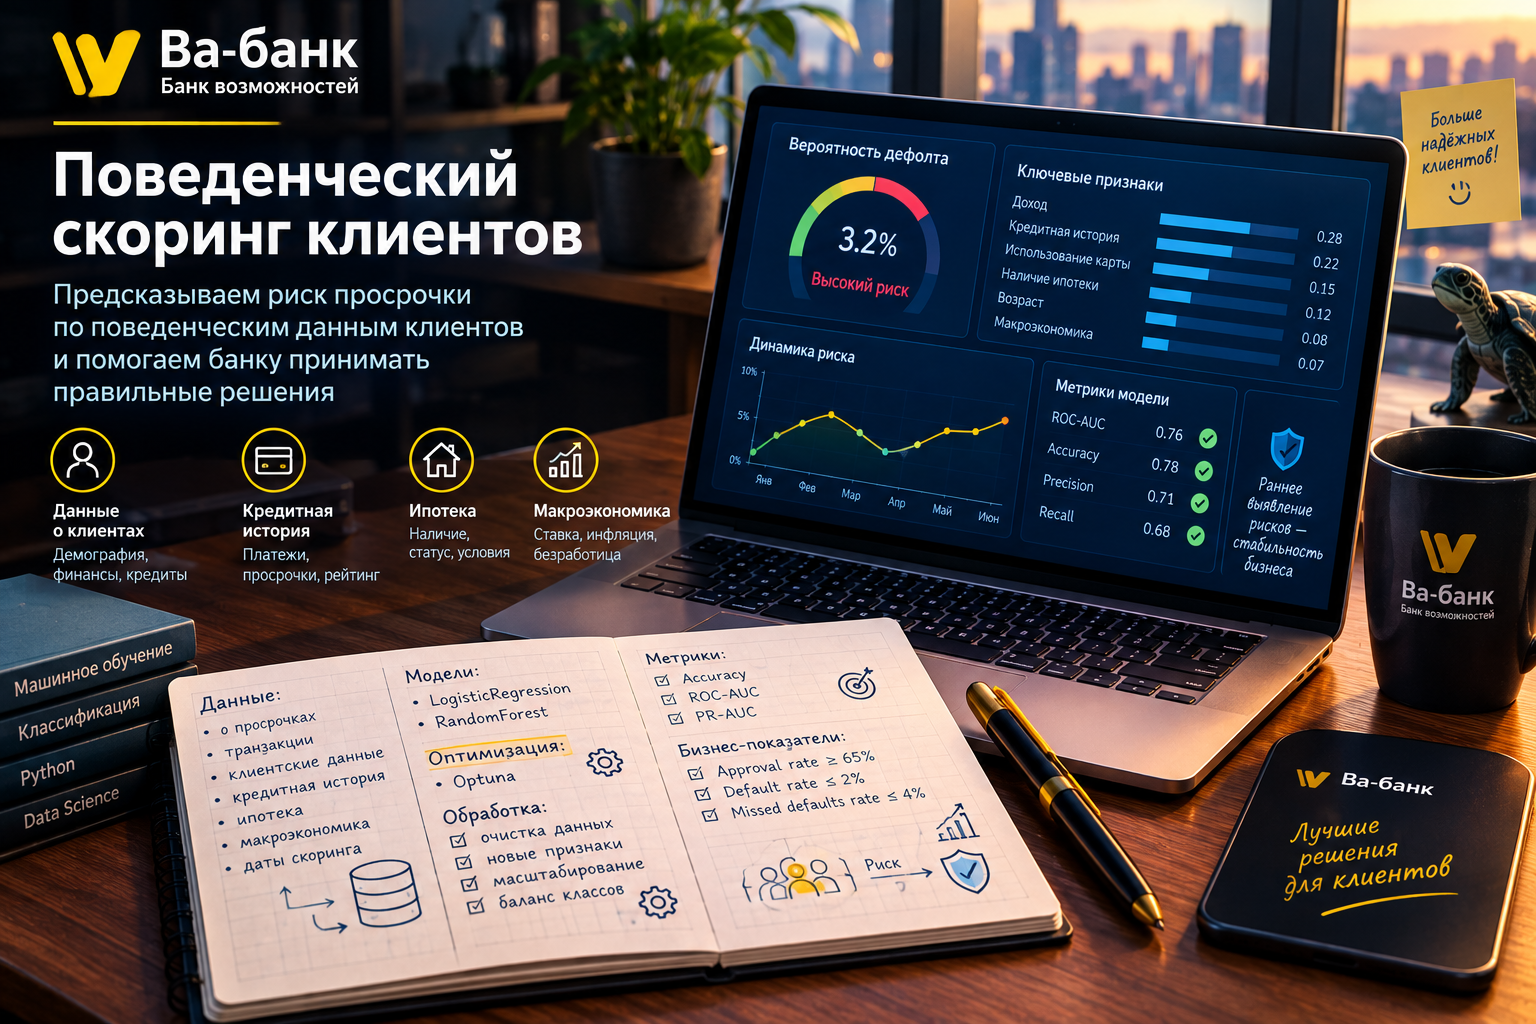

<a id='p1'></a>

---

## Подготовка рабочего пространства

<span style="font-size: 18px;">**Цель проекта**</span>

Разработать модель поведенческого скоринга, которая по данным о поведении действующего клиента банка в конкретном месяце прогнозирует возникновение просрочки длительностью 90 дней и более в течение следующих 12 месяцев.

Модель должна учитывать финансовое поведение клиента, его социально-демографические характеристики, кредитную историю, наличие ипотеки и макроэкономические показатели. Основная задача - заранее выявлять клиентов с повышенным риском дефолта и подобрать порог классификации, обеспечивающий приемлемый баланс между долей клиентов, которых модель считает надёжными, и количеством пропущенных дефолтов. Такой подход соответствует назначению поведенческого скоринга - выявлять ранние признаки роста кредитного риска у уже действующих клиентов банка.

<span style="font-size: 18px;">**Задачи проекта**</span>

В рамках указанной цели необходимо решить задачу бинарной классификации. Для её решения требуется выполнить следующие шаги:

1. Первичный анализ структуры и качества данных по каждой таблице.
2. Исследовательский анализ данных: проверка пропусков, дубликатов, выбросов и других особенностей.
3. Формирование датафрейма для обучения моделей и выделение целевой переменной.
4. Создание новых признаков.
5. Разделение данных на обучающую, калибровочную и тестовую выборки с учётом временной структуры.
6. Построение базовых моделей `LogisticRegression` и `RandomForestClassifier`.
7. Сравнение моделей на исходных несбалансированных данных и с применением методов балансировки классов.
8. Построение итоговой модели `RandomForestClassifier` и определение оптимальных гиперпараметров с помощью `Optuna`.
9. Калибровка вероятностных предсказаний лучшей модели.
10. Анализ важности признаков.
11. Формулирование итоговых выводов и рекомендаций по дальнейшему использованию модели.

Требования к решению включают использование `Random Forest` в качестве основной модели, трёхфолдовой кросс-валидации с `GroupTimeSeriesSplit()` и подбор не менее трёх гиперпараметров с помощью `Optuna`.

<a id='p2'></a>

---

## Постановка задачи машинного обучения

Задача проекта относится к обучению с учителем и является задачей бинарной классификации. Для каждого клиента в определённый месяц необходимо на основании доступной на этот момент информации оценить вероятность того, что в течение следующих 12 месяцев у клиента возникнет просрочка длительностью 90 дней или более.

Целевая переменная формируется следующим образом:
- `1` - если в течение следующих 12 месяцев возникает просрочка длительностью 90 дней и более;
- `0` - если такая просрочка в заданном горизонте не возникает.

В качестве базовых моделей будут рассмотрены:
- `LogisticRegression` - базовая линейная модель бинарной классификации;
- `RandomForestClassifier` - ансамблевая модель на основе решающих деревьев.

Для решения проблемы дисбаланса классов будут исследованы различные стратегии балансировки: `class_weight`, `RandomOverSampler`, `RandomUnderSampler`, `SMOTE`. Таким образом, будет проведено сравнение моделей, обученных как на исходных данных, так и с применением методов балансировки классов.

В качестве итогового алгоритма будет использован `RandomForestClassifier`. Для оценки его качества будет применяться кросс-валидация с тремя фолдами и временным разделением данных посредством `GroupTimeSeriesSplit()`, чтобы при обучении и проверке сохранялась временная структура наблюдений. Гиперпараметры модели планируется оптимизировать с помощью `Optuna`.

<span style="font-size: 18px;">**Метрики оценки**</span>

Качество модели будет оцениваться с помощью технических и бизнес-метрик. Основные бизнес-метрики:
- `Approval rate` = $\frac{FN + TN}{N}$ - доля клиентов, которых модель относит к надёжным (0).
- `Default rate` = $\frac{FN}{FN + TN}$ - доля клиентов с фактическим дефолтом среди клиентов, которых модель признала надёжными.
- `Missed defaults rate` = $\frac{FN}{FN + TP}$ = $1-Recall$ - доля дефолтов, которые модель не обнаружила.

Здесь $FN$ - клиенты, которые модель ошибочно посчитала надёжными; TN - клиенты, которые модель правильно посчитала надёжными; $N$ - общее число клиентов.

Дополнительно для сравнения моделей будут использоваться технические метрики: `Accuracy`, `ROC-AUC` или `PR-AUC`.

При выборе порога классификации необходимо одновременно обеспечить следующие условия:
- `Approval rate` $\ge$ 65%;
- `Default rate` $\le$ 2%;
- `Missed defaults rate` $\le$ 4%.

<span style="font-size: 18px;">**Описание данных**</span>

Для решения задачи предоставлено несколько таблиц, содержащих информацию о клиентах, их финансовом поведении, кредитах, рейтинге и макроэкономической ситуации. Все источники должны быть объединены в единую таблицу наблюдений перед построением моделей.

1. Данные о просрочках - `ds_15_loan_payment_credit.csv`. Содержат информацию о фактах просрочки:
    - `ID` - идентификатор клиента;
    - `дата_начала_периода` - дата начала периода просрочки;
    - `просрочка_дней` - длительность просрочки в днях.
2. Месячные транзакции - `ds_15_transactions.csv`. Содержат помесячные расходы клиента по категориям MCC:
    - `ID`;
    - `date`;
    - `MCC_5300`;
    - `MCC_5814`;
    - `MCC_5812`;
    - `MCC_5411`;
    - `MCC_3990`;
    - `MCC_5722`;
    - `MCC_4900`;
    - `MCC_другое`.
- Эти признаки характеризуют структуру и объём расходов клиента по различным категориям.
3. Описание клиента - `ds_15_client_description.csv`. Содержит характеристики клиента на момент регистрации:
    - `ID`;
    - `возраст`;
    - `семейное_положение`;
    - `наличие_иждивенцев`;
    - `дата_регистрации`.
4. Описание кредита - `ds_15_credit_description.csv`. Содержит финансовые характеристики кредита:
    - `ID`;
    - `доход`;
    - `сумма_кредита`.
5. Данные об ипотеке - `ds_15_mortgage_presence.csv`. Содержат:
    - `ID`;
    - `дата_открытия`;
    - `наличие_ипотеки`.
6. Кредитный рейтинг - `ds_15_credit_rating.csv`. Содержит динамическую информацию о кредитном рейтинге:
    - `ID`;
    - `date`;
    - `кредитный_рейтинг`.
7. Макроэкономические показатели - `ds_15_macro_data.csv`. Содержат значения показателей по месяцам:
    - `date`;
    - `учетная_ставка`;
    - `уровень_безработицы`;
    - `инфляция`.
8. Таблица дат поведенческого скоринга - `ds_15_cohort_grid.csv`. Содержит:
    - `ID` - идентификатор клиента;
    - `score_date` - дата проведения поведенческого скоринга.
- Эта таблица используется для определения набора наблюдений «клиент–месяц»

<a id='contents'></a>

---

<span style="font-size: 18px;">**Оглавление**</span>

1. [Подготовка рабочего пространства](#p1)
2. [Постановка задачи машинного обучения](#p2)
3. [Загрузка необходимых библиотек](#p3)
4. [Загрузка данных](#p4)
5. Исследовательский анализ данных (EDA)
    - [Таблица дат поведенческого скоринга - `ds_15_cohort_grid.csv`](#p5a)
    - [Описание клиента - `ds_15_client_description.csv`](#p5b)
    - [Описание выданного кредита - `ds_15_credit_description.csv`](#p5c)
    - [Данные об ипотеке - `ds_15_mortgage_presence.csv`](#p5d)
    - [Кредитный рейтинг - `ds_15_credit_rating.csv`](#p5e)
    - [Макроэкономические показатели `ds_15_macro_data.csv`](#p5f)
    - [Месячные транзакции - `ds_15_transactions.csv`](#p5g)
    - [Данные о просрочках - `ds_15_loan_payment_credit.csv`](#p5h)
6. Объединение таблиц
    - [Формирование целевой переменной](#p6a)
    - [Создание итоговой таблицы](#p6b)
    - [Создание новых признаков](#p6c)
    - [Анализ итоговой таблицы (выводы по EDA)](#p6d)
7. Моделирование
    - [Логистическая регрессия](#p7a)
    - [Случайный лес](#p7b)
    - [Сравнение и выводы по моделям](#p7c)
8. [Калибровка модели и пересчёт результатов](#p8)
9. [Поиск порога решения](#p9)
10. [Анализ матрицы ошибок](#p10)
11. [Фиксирование итоговой модели](#p11)
12. [Анализ важности признаков](#p12)
13. [Выводы по проекту](#p13)

<a id='p3'></a>

---

## Загрузка необходимых библиотек

Загрузим все библиотеки, необходимые для выполнения проекта.

[К Содержимому проекта](#contents)

In [1]:
# Установка библиотек
# !pip install mlxtend -Uq
# !pip install optuna -Uq
# !pip install imblearn -Uq

try:
    !pip freeze > "../requirements.txt"
except Exception:
    !pip freeze > "requirements.txt"

In [2]:
# Основные библиотеки для работы с датафреймами, визуализацией, а также вспомогательные
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib
import sys
from dateutil.relativedelta import relativedelta

# Для работы с выборками
from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit, 
    plot_splits, 
    print_cv_info, 
    print_split_info
)

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Предобработка и пайплайн
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Балансировка классов
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Поиск гиперпараметров
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Метрики
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix
)
# Модули для калибровки
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

In [3]:
# Фиксирую состояние и дополнительный класс для более качественного вывода
random_state = 42
class color:
    """
    Класс для форматирования текста в терминале
    """

    PURPLE = "\033[95m"
    CYAN = "\033[96m"
    DARKCYAN = "\033[36m"
    BLUE = "\033[94m"
    GREEN = "\033[92m"
    YELLOW = "\033[93m"
    RED = "\033[91m"
    BOLD = "\033[1m"
    UNDERLINE = "\033[4m"
    END = "\033[0m"  # сбросить все стили (возврат к нормальному виду)

<a id='p4'></a>

---

## Загрузка данных

Загрузим предоставленные данные и посмотрим их содержимое. Сделаем первые выводы о них.

[К Содержимому проекта](#contents)

In [4]:
try:
    # Локальная версия
    df = pd.read_csv('../datasets/ds_15_loan_payment_credit.csv')
    prefix_str = '../datasets/'
except FileNotFoundError:
    prefix_str = '/datasets/'

for name in ['ds_15_loan_payment_credit.csv', 'ds_15_transactions.csv', 'ds_15_client_description.csv', 
             'ds_15_credit_description.csv', 'ds_15_mortgage_presence.csv', 'ds_15_credit_rating.csv', 'ds_15_macro_data.csv',
             'ds_15_cohort_grid.csv']:
    
    df = pd.read_csv(prefix_str + name)
    
    print(color.BOLD + color.PURPLE + '\nИнформация по ' + name + ':' + color.END)
    print(color.BOLD + color.BLUE + 'Случайные пять строк:' + color.END)
    display(df.sample(n=5, random_state = random_state))
    print(color.BOLD + color.RED + '\nОсновая информация по датасету:\n' + color.END)
    df.info()
    print(color.BOLD + color.GREEN + '\nСтатистическая информация по датасету:\n' + color.END)
    display(df.describe().T)
    display(df.select_dtypes(include=["object", "string", "category"]).describe().T)


Информация по ds_15_loan_payment_credit.csv:
Случайные пять строк:


,ID,дата_начала_периода,просрочка_дней
4747,IDF55128528,2019-05-01,107
1199,IDF55064924,2014-04-01,80
5222,IDF55102721,2019-02-01,88
4547,IDF55086294,2019-11-01,127
1862,IDF55026134,2014-10-01,96



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   5500 non-null   str  
 1   дата_начала_периода  5500 non-null   str  
 2   просрочка_дней       5500 non-null   int64
dtypes: int64(1), str(2)
memory usage: 129.0 KB

Статистическая информация по датасету:



,count,mean,std,min,25%,50%,75%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,97.0,115.0,132.0,150.0


,count,unique,top,freq
ID,5500,5500,IDF55109846,1
дата_начала_периода,5500,73,2018-12-01,209


...


Информация по ds_15_cohort_grid.csv:
Случайные пять строк:


,ID,score_date
178212,IDF55105942,2018-03-01
416528,IDF54898911,2017-10-01
276699,IDF54924544,2015-12-01
214290,IDF55047255,2016-02-01
373505,IDF55031672,2017-04-01



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ID          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB

Статистическая информация по датасету:



,count,unique,top,freq
ID,577494,13500,IDF55014574,84
score_date,577494,84,2019-12-01,13500


,count,unique,top,freq
ID,577494,13500,IDF55014574,84
score_date,577494,84,2019-12-01,13500


<span style="font-size: 16px;">**Итог**</span>

По итогам первичного знакомства можно прийти к следующим выводам:
- Вероятно, в данных содержится информация о 13500 клиентах, из которых просрочки имеют 5500 клиентов.
- Информация предоставлена за 84 месяца, т.е. 7 лет. В таком случае общее количество уникальных пар клиент - месяц должно быть 1 134 000, но судя по таблицам `ds_15_cohort_grid.csv`, `ds_15_credit_rating.csv`, `ds_15_transactions` всего о 577 494 парах. Таким образом часть клиентов не была клиентами банка на всем временном периоде и появилась только недавно или информация отсутствует для некоторых пар.
- Большинство типов соответствует ожиданию, кроме дат. Они были определены как строки.
- Имена столбцов по написанию соответствует стандарту, принятому в python, единственное 'но' - они написаны на кириллице. Здесь, вероятно, стоит их переименовать, т.к. со временем могут возникнуть неожиданные проблемы.
- Стратегия по сбору информации и формированию единого датафрема будет заключаться в следующем:
    * Первым рассматриваем `ds_15_cohort_grid.csv`, т.к. он содержит полный набор пар.
    * Используя полное соединение, добавляем таблицы, содержащие единственный ключ (или дату или ID клиента). Объединенную таблицу проверяем на пропуски, выбросы, дубликаты и принимаем решения по их обработки.
    * Используя полное внешнее соединение, присоединяем таблицы с парами (и ID и дату). Также проверяем на пропуски, выбросы, дубликаты.

<a id='p5a'></a>

---

## Исследовательский анализ данных (EDA)

- Проведем первичный анализ данных. Алгоритм был приведен выше в итогах.
- Сделаем выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.
- Далее соберем эти действия в единую процедуру для обработки в рамках единого pipeline. При объединении используем полное внешнее соединение, а также соединяем по равенству дат. При формировании итоговой таблицы в случае необходимости будем использовать сдвиг.

---

### Таблица дат поведенческого скоринга - `ds_15_cohort_grid.csv`

[К Содержимому проекта](#contents)

In [5]:
# Подпрограмма для визуализации распределения признаков
def plot_cat_num_target(df_in, type_f = 'Num', target_dict = None, exclude_cols=None, figsize=(15, 15), ncols=3):
    df = df_in.copy()
    
    if type_f == 'Num':
        bools_list = list(df.select_dtypes(include = ['boolean']).columns)
        df[bools_list] = df[bools_list].astype(int)
        cols = list(df.select_dtypes(include = ['int', 'float']).columns)
    elif type_f == 'Cat':
        cols = list(df.select_dtypes(include = ['object', 'category', 'string']).columns)
    if exclude_cols:
            cols = [col for col in cols if col not in exclude_cols]
    
    
    if target_dict is None:
        if type_f == 'Num':
            df[cols].hist(figsize = figsize)
            plt.show()
        elif type_f == 'Cat':
            n_feat = len(cols)
            nrows = math.ceil(n_feat / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
            for k, col in enumerate(cols):
                i, j = divmod(k, ncols)
                ax = axes[i, j]
                df[col].value_counts(dropna=False).plot.barh(ax=ax, edgecolor='black')
                ax.set_title(col, fontsize=12)
                ax.set_xlabel('Количество')
                ax.set_ylabel('')
            plt.show()
    else:
        name_t = target_dict['name_t']
        type_t = target_dict['type_t']
        
        if (type_f == 'Cat') and (type_t == 'Cat'):
            cols.remove(name_t)
            n_feat = len(cols)
            nrows = math.ceil(n_feat / ncols)
            
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
            for k, col in enumerate(cols):
                i, j = divmod(k, ncols)
                ax = axes[i, j]
                ctab = pd.crosstab(df[col], df[name_t], dropna=False)
                
                ctab.plot.barh(ax=ax, legend=False, edgecolor='black')
                ax.set_title(col, fontsize=12)
                ax.set_xlabel('Количество')
                ax.set_ylabel(col)
            
            handles, labels = ax.get_legend_handles_labels()
            fig.legend(handles, labels, title=target_col, loc='upper right', bbox_to_anchor=(1.0, 1.0))
            plt.tight_layout()
            plt.show()
            
        else:
            sns.set_context("notebook", font_scale=1.0)
            if name_t in cols:
                cols.remove(name_t)
            
            for col in cols:
                g = sns.jointplot( data=df, x=col, y=name_t, height=4,
                                  marginal_kws={'linewidth': 1, 'edgecolor': 'black', 'alpha': 0.5},
                                  joint_kws={'s': 40, 'alpha': 0.5, 'edgecolor': 'none'})
                g.set_axis_labels(col, name_t, fontsize=12)
                g.ax_joint.grid(True, alpha=0.3)
                
                for patch in g.ax_marg_x.patches:
                    patch.set_linewidth(1.5)
                    patch.set_edgecolor('black')
                for patch in g.ax_marg_y.patches:
                    patch.set_linewidth(1.5)
                    patch.set_edgecolor('black')
                
                plt.show()

#### Пропуски

In [6]:
df = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')

df['score_date'] = pd.to_datetime(df['score_date'], format='%Y-%m-%d')
df.info()
print(color.BOLD + color.BLUE + '\nСтолбец и количество уникальных значений в нем:' + color.END)
display(df.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   score_date  577494 non-null  datetime64[us]
dtypes: datetime64[us](1), str(1)
memory usage: 8.8 MB

Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,ID,13500
1,score_date,84


Пропусков не заметно.

#### Дубликаты

In [7]:
display(df[df.duplicated(subset=['ID','score_date'], keep=False)].sort_values(by=['ID'], ascending=False))

,ID,score_date


Дубликатов нет.

#### Аномалии

Проверим, есть-ли пропуски в непрерывном ряде дат для конкретного клиента.

In [8]:
df = df.sort_values(['ID', 'score_date'])

month_num = df['score_date'].dt.year * 12 + df['score_date'].dt.month
month_diff = month_num.groupby(df['ID']).diff()
ids_with_gaps = df.loc[month_diff > 1, 'ID'].unique()

print(f'Количество пользователей с пропусками: {len(ids_with_gaps)}')
print(ids_with_gaps)

Количество пользователей с пропусками: 0
<StringArray>
[]
Length: 0, dtype: str


Аномалий не замечено.

<a id='p5b'></a>

---

### Описание клиента - `ds_15_client_description.csv`

[К Содержимому проекта](#contents)

In [9]:
df_pr = pd.read_csv(prefix_str + 'ds_15_client_description.csv')

df_pr.columns = df_pr.columns.str.replace({'возраст':'age', 'семейное_положение':'marital_status', 
                                           'наличие_иждивенцев':'dependents', 'дата_регистрации':'registration_date'})
df_pr['registration_date'] = pd.to_datetime(df_pr['registration_date'], format='%Y-%m-%d')

df = pd.merge(df, df_pr, on = 'ID', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   registration_date  577494 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(2), str(2)
memory usage: 26.4 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

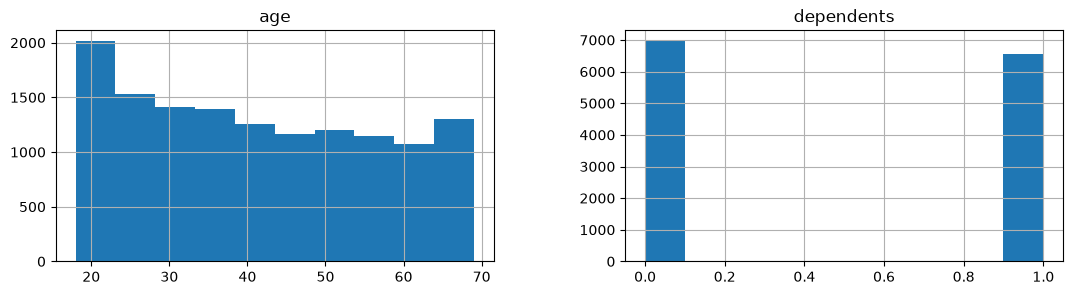

In [10]:
plot_cat_num_target(df_pr, type_f = 'Num', target_dict = None, exclude_cols=['ID', 'score_date'], figsize=(13, 3))

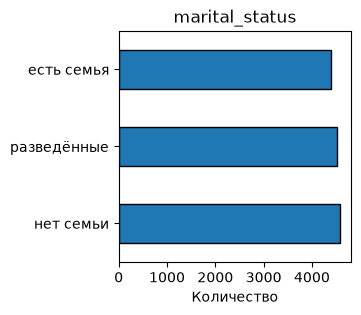

In [11]:
plot_cat_num_target(df_pr, type_f = 'Cat', target_dict = None, exclude_cols=['ID'], figsize=(3, 3), ncols=1)

Заметны пиковые значения на концах для возраста. Фактически рост к краю интервала, что не типично, однако, возможно. `registration_date` - данный признак не должен влиять на целевую переменную, поэтому после некоторых проверок далее удалим его из датасета.

<a id='p5c'></a>

---

### Описание выданного кредита - `ds_15_credit_description.csv`

[К Содержимому проекта](#contents)

In [12]:
df_pr = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')

df_pr.columns = df_pr.columns.str.replace({'доход':'income', 'сумма_кредита':'loan_amount'})
df = pd.merge(df, df_pr, on = 'ID', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   registration_date  577494 non-null  datetime64[us]
 6   income             577494 non-null  int64         
 7   loan_amount        577494 non-null  int64         
dtypes: datetime64[us](2), int64(4), str(2)
memory usage: 35.2 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

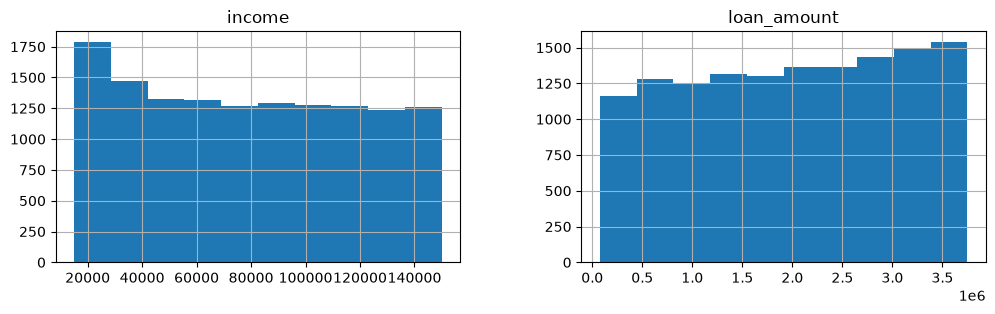

In [13]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(12, 3), ncols=2)

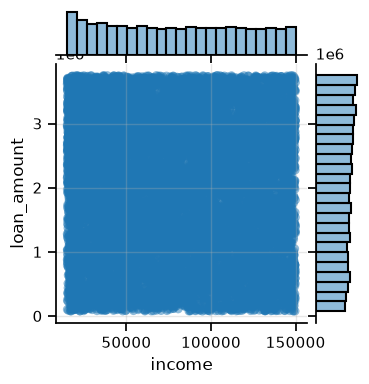

In [14]:
plot_cat_num_target(df_pr, type_f = 'Num', target_dict = {'name_t':'loan_amount', 'type_t':'Num'}, figsize=(10, 4), ncols=1)

В целом выбросов не заметно, аномальным, пожалуй, можно посчитать то, что ярко выраженная связь между суммой кредита и доходом не заметна.

<a id='p5d'></a>

---

### Данные об ипотеке - `ds_15_mortgage_presence.csv`

[К Содержимому проекта](#contents)

In [15]:
df_pr = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')

df_pr.columns = df_pr.columns.str.replace({'дата_открытия':'opening_date', 'наличие_ипотеки':'mortgage'})    
df_pr['opening_date'] = pd.to_datetime(df_pr['opening_date'], format='%Y-%m-%d')
df = pd.merge(df, df_pr, on = 'ID', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   registration_date  577494 non-null  datetime64[us]
 6   income             577494 non-null  int64         
 7   loan_amount        577494 non-null  int64         
 8   opening_date       280733 non-null  datetime64[us]
 9   mortgage           280733 non-null  float64       
dtypes: datetime64[us](3), float64(1), int64(4), str(2)
memory usage: 44.1 MB


#### Пропуски, дубликаты, аномалии

Дубликатов нет. Заметно появление пропусков после соединения таблиц. Столбец `наличие_ипотеки` необходимо заполнить нулем в случае пропуска. В случае столбца `дата_открытия` нужно проверить на аномальные значения.

In [16]:
df[df['registration_date'] == df['opening_date']].shape[0]

280733

**Выводы:** если клиент зарегистрировался в банке, то он открыл ипотеку в этот месяц. Следовательно, можно спокойно заполнять 0 все пропуск в столбце `наличие_ипотеки`. Столбец `дата_открытия` можно удалять, т.к. он фактически заменяем столбцом `наличие_ипотеки` во временном ряду для целевой переменной.

In [17]:
df = df.drop(columns = ['opening_date', 'registration_date']).copy()
df['mortgage'] = df['mortgage'].fillna(0)
df['mortgage'] = df['mortgage'].astype(int)
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
score_date,577494,2017-08-08 08:44:17.407350,2013-01-01 00:00:00,2016-06-01 00:00:00,2017-12-01 00:00:00,2019-01-01 00:00:00,2019-12-01 00:00:00,NaN
age,577494.0,41.395092,18.0,28.0,40.0,54.0,69.0,15.153399
dependents,577494.0,0.484828,0.0,0.0,0.0,1.0,1.0,0.49977
income,577494.0,78778.273305,15010.0,42689.0,77751.0,113707.0,149988.0,40232.320781
loan_amount,577494.0,1989594.30646,75000.0,1078620.0,2029470.0,2910645.0,3749400.0,1061552.204712
mortgage,577494.0,0.486123,0.0,0.0,0.0,1.0,1.0,0.499808


#### Выбросы

Выбросов не замечано.

<a id='p5f'></a>

---

### Макроэкономические показатели `ds_15_macro_data.csv`

[К Содержимому проекта](#contents)

In [18]:
df_pr = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')

df_pr.columns = df_pr.columns.str.replace({'date':'score_date', 'учетная_ставка':'discount_rate', 
                                           'уровень_безработицы' : 'unemployment_rate', 'инфляция':'inflation'})
df_pr['score_date'] = pd.to_datetime(df_pr['score_date'], format='%Y-%m-%d')
df = pd.merge(df, df_pr, on = 'score_date', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(5), str(2)
memory usage: 48.5 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

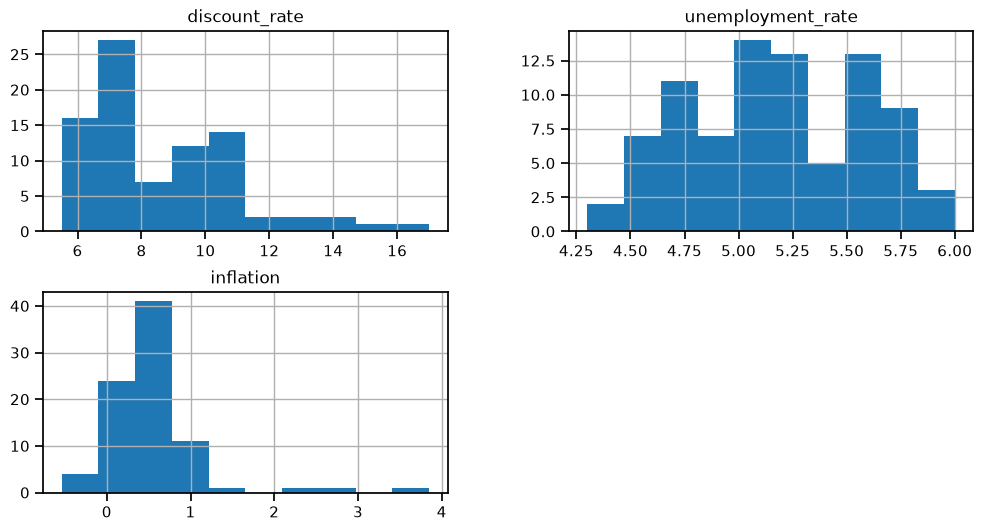

In [19]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(12, 6), ncols=3)

Заметны смещения в значениях, однако, значения в рамках реальных значений (инфляция может быть отрицательной).

<a id='p5e'></a>

---

### Кредитный рейтинг - `ds_15_credit_rating.csv`

[К Содержимому проекта](#contents)

In [20]:
df_pr = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')
    
df_pr['date'] = pd.to_datetime(df_pr['date'], format='%Y-%m-%d')
df_pr.columns = df_pr.columns.str.replace({'date':'score_date', 'кредитный_рейтинг':'credit_rating'})
df = pd.merge(df, df_pr, on = ['ID', 'score_date'], how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(6), str(2)
memory usage: 52.9 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

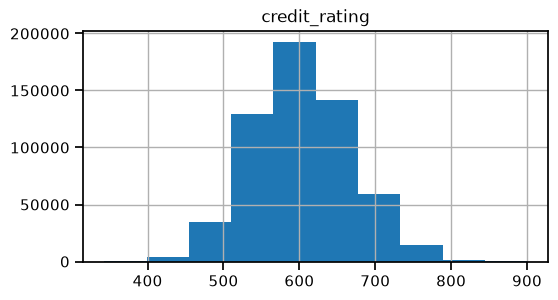

In [21]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(6, 3), ncols=1)

In [22]:
display(df_pr.describe().T)

,count,mean,min,25%,50%,75%,max,std
score_date,577494,2017-08-08 08:44:17.407349,2013-01-01 00:00:00,2016-06-01 00:00:00,2017-12-01 00:00:00,2019-01-01 00:00:00,2019-12-01 00:00:00,NaN
credit_rating,577494.0,603.190961,343.0,558.0,600.0,646.0,900.0,64.358896


Распределение практически нормальное. Ярко выраженных выбросов нет.

<a id='p5g'></a>

---

### Месячные транзакции - `ds_15_transactions.csv`

[К Содержимому проекта](#contents)

In [23]:
df_pr = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

df_pr['date'] = pd.to_datetime(df_pr['date'], format='%Y-%m-%d')
df_pr.columns = df_pr.columns.str.replace({'date':'score_date', 'MCC_5300':'mcc_5300', 'MCC_5814':'mcc_5814',
                                           'MCC_5812':'mcc_5812', 'MCC_5411':'mcc_5411', 'MCC_3990':'mcc_3990',
                                           'MCC_5722':'mcc_5722', 'MCC_4900':'mcc_4900', 'MCC_другое':'mcc_other'})
df = pd.merge(df, df_pr, on = ['ID', 'score_date'], how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
 12  mcc_5300           577494 non-null  float64       
 13  mcc_5814           577494 non-null  float64       
 14 

#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

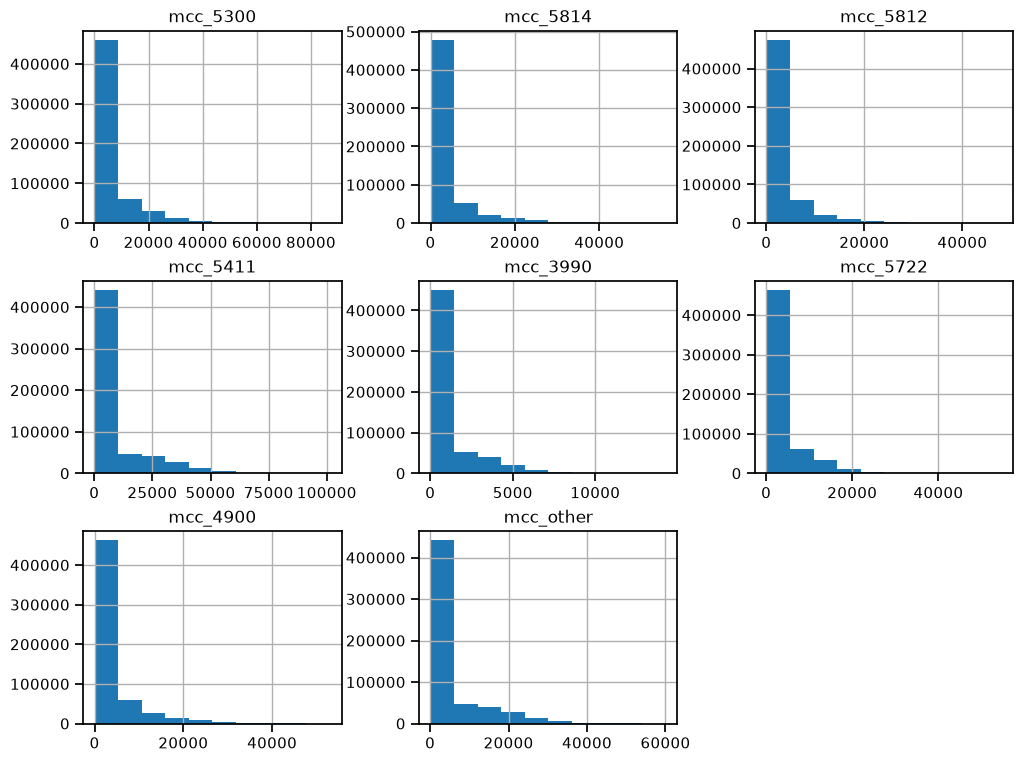

In [24]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(12, 9), ncols=3)

In [25]:
df[df['income'] < df['mcc_5300'] + df['mcc_5814'] + df['mcc_5812'] + df['mcc_5411'] + df['mcc_3990'] + df['mcc_5722'] + df['mcc_4900'] + df['mcc_other']]

,ID,score_date,age,marital_status,dependents,income,loan_amount,mortgage,discount_rate,unemployment_rate,inflation,credit_rating,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_other
7,IDF54896351,2013-10-01,39,нет семьи,1,17633,2506575,1,5.500000,5.4,0.57,670,5122.73,902.46,2841.36,4435.89,421.12,1569.14,1190.45,2522.18
8,IDF54896351,2013-11-01,39,нет семьи,1,17633,2506575,1,5.500000,5.5,0.56,667,5840.47,950.16,2765.82,4591.17,502.54,1627.49,1255.01,2613.11
9,IDF54896351,2013-12-01,39,нет семьи,1,17633,2506575,1,5.500000,5.6,0.51,656,5649.05,959.05,1711.16,4095.09,461.31,1904.80,1240.07,2664.86
13,IDF54896351,2014-04-01,39,нет семьи,1,17633,2506575,1,7.068182,4.9,0.90,675,2994.63,2302.93,1275.00,5474.93,955.62,1905.33,4513.13,3011.57
14,IDF54896351,2014-05-01,39,нет семьи,1,17633,2506575,1,7.500000,5.0,0.90,671,3192.76,3689.33,1312.72,5563.09,1117.07,1926.20,3923.80,3020.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577459,IDF55151667,2017-02-01,32,разведённые,0,51953,2848485,0,10.000000,5.5,0.22,654,11504.16,3286.15,10075.74,22527.83,1553.69,6265.60,4568.67,11831.07
577460,IDF55151667,2017-03-01,32,разведённые,0,51953,2848485,0,9.943182,5.6,0.13,643,18959.16,3462.52,11832.47,21608.26,1830.63,5940.48,4829.74,9953.81
577461,IDF55151667,2017-04-01,32,разведённые,0,51953,2848485,0,9.750000,5.3,0.33,633,18795.52,3113.61,9309.25,14884.15,1609.56,5986.88,4294.84,9139.55
577462,IDF55151667,2017-05-01,32,разведённые,0,51953,2848485,0,9.250000,5.2,0.37,630,25844.09,4584.75,8891.72,20818.91,2214.44,9603.34,5919.49,13044.96


Заметны месяца для некоторых клиентов в которые они больше тратят чем зарабатывают. Причем таких сочетаний пользователь - месяц достаточно много. В будущем данное наблюдение можно использовать для создания новых признаков. Представленные значения в целом укладываются в разумные значения, без выраженных выбросов.

<a id='p5h'></a>

---

### Данные о просрочках - `ds_15_loan_payment_credit.csv`

[К Содержимому проекта](#contents)

In [26]:
df_pr = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')

df_pr['дата_начала_периода'] = pd.to_datetime(df_pr['дата_начала_периода'], format='%Y-%m-%d')
df_pr.columns = df_pr.columns.str.replace({'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})
df = pd.merge(df, df_pr, on = ['ID'], how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
 12  mcc_5300           577494 non-null  float64       
 13  mcc_5814           577494 non-null  float64       
 14 

#### Пропуски, дубликаты

Количество строк не изменилось при присоединении следовательно не появляется дубликатов. Пропуски имеются только в столбцах `start_date` и `days_overdue`. Для `days_overdue` логично заполнять пропуски 0, т.к. пользователь не имеет просрочки в днях. `start_date` необходим только для создания целевой переменной, после ее создания он может быть удален, поэтому заполним его флаговой датой, не мешающей заполнению целевой переменной. Например, два века до минимального значения `score_date`.

In [27]:
df['days_overdue'] = df['days_overdue'].fillna(0)
df['days_overdue'] = df['days_overdue'].astype(int)
mindt = df['score_date'].min() - relativedelta(years=200)
df['start_date'] = df['start_date'].fillna(mindt)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
 12  mcc_5300           577494 non-null  float64       
 13  mcc_5814           577494 non-null  float64       
 14 

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

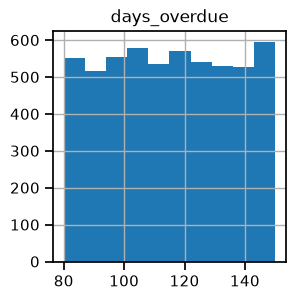

In [28]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(3, 3), ncols=3)

In [29]:
display(df_pr.select_dtypes(include=["datetime"]).describe().T)

,count,mean,min,25%,50%,75%,max
start_date,5500,2017-06-15 23:24:54.981818,2013-11-01 00:00:00,2015-12-01 00:00:00,2017-09-01 00:00:00,2019-02-01 00:00:00,2019-12-01 00:00:00


Откровенных выбрасов или аномалий в таблице не заметно. 

<a id='p6a'></a>

---

## Объединение таблиц

Последовательно опишем алгоритм объединения таблиц и сохраним его отдельно. Начнем с алгоритма по формированию целевой переменной.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.
2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.
3. После расчёта целевой переменной удалим строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. У клиента может быть несколько эпизодов с просрочками от 90 дней. Нам нужно взять первый по времени возникновения эпизод в таблице с просрочками. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

[К Содержимому проекта](#contents)

In [30]:
cohort = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')

cohort["score_date"] = pd.to_datetime(cohort["score_date"])
loans["дата_начала_периода"] = pd.to_datetime(loans["дата_начала_периода"])
loans.columns = loans.columns.str.replace({'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})

loans = loans.loc[loans["days_overdue"] >= 90, ["ID", "start_date"]]
first_default = loans.groupby("ID", as_index=False)["start_date"].min()

cohort = pd.merge(cohort, first_default, how = 'left', on = ['ID'])
cohort = cohort[cohort["start_date"].isna() | (cohort["start_date"] >= cohort["score_date"])].copy()

cohort["target"] = (cohort["start_date"].notna() & 
                    (cohort["start_date"] < cohort["score_date"] + pd.Timedelta(days=365))).astype(int)
cohort = cohort.sort_values(['score_date', 'ID'])
cohort = cohort.reset_index().drop(columns = ['index'])

print(color.BOLD + color.BLUE + 'Случайные пять строк:' + color.END)
display(cohort.sample(n=10, random_state = random_state))
print(color.BOLD + color.RED + 'Проблемный клиент:' + color.END)
display(cohort[cohort['ID'] == 'IDF55010107'])

print(color.BOLD + color.RED + '\nОсновая информация по датасету:\n' + color.END)
cohort.info()

Случайные пять строк:


,ID,score_date,start_date,target
309549,IDF55141282,2018-09-01,NaT,0
385606,IDF55148143,2019-06-01,NaT,0
91289,IDF55144936,2015-11-01,NaT,0
174723,IDF54961339,2017-03-01,NaT,0
238810,IDF55095653,2017-12-01,NaT,0
200227,IDF54950176,2017-07-01,NaT,0
55022,IDF55010107,2015-03-01,2016-07-01,0
103788,IDF55042264,2016-02-01,NaT,0
80943,IDF55077746,2015-09-01,NaT,0
113542,IDF55024508,2016-04-01,NaT,0


Проблемный клиент:


,ID,score_date,start_date,target
44159,IDF55010107,2014-12-01,2016-07-01,0
47675,IDF55010107,2015-01-01,2016-07-01,0
51287,IDF55010107,2015-02-01,2016-07-01,0
55022,IDF55010107,2015-03-01,2016-07-01,0
58877,IDF55010107,2015-04-01,2016-07-01,0
62818,IDF55010107,2015-05-01,2016-07-01,0
66872,IDF55010107,2015-06-01,2016-07-01,0
71048,IDF55010107,2015-07-01,2016-07-01,0
75308,IDF55010107,2015-08-01,2016-07-01,1
79693,IDF55010107,2015-09-01,2016-07-01,1



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          438379 non-null  str           
 1   score_date  438379 non-null  datetime64[us]
 2   start_date  62173 non-null   datetime64[us]
 3   target      438379 non-null  int64         
dtypes: datetime64[us](2), int64(1), str(1)
memory usage: 13.4 MB


<a id='p6b'></a>

---

### Создание итоговой таблицы

Опишем итогоую процедуру по созданию датафрейма для обучения, валидации, тестирования и калибровки. При создании будем придерживаться ряда правил:
1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.
>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.
2. Остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента, присоединим без сдвига.
3. Выводы о получившейся таблице будут приведены [далее](#p6d).

[К Содержимому проекта](#contents)

In [31]:
def DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    cohorts["score_date"] = pd.to_datetime(cohorts["score_date"])
    loans["дата_начала_периода"] = pd.to_datetime(loans["дата_начала_периода"])
    loans.columns = loans.columns.str.replace({'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})
    
    loans = loans.loc[loans["days_overdue"] >= 90, ["ID", "start_date"]]
    first_default = loans.groupby("ID", as_index=False)["start_date"].min()
    cohorts = pd.merge(cohorts, first_default, how = 'left', on = ['ID'])
    cohorts = cohorts[cohorts["start_date"].isna() | (cohorts["start_date"] >= cohorts["score_date"])].copy()
    
    cohorts["target"] = (cohorts["start_date"].notna() & 
                        (cohorts["start_date"] < cohorts["score_date"] + pd.Timedelta(days=365))).astype(int)
    cohorts = cohorts.sort_values(['score_date', 'ID'])
    cohorts = cohorts.reset_index().drop(columns = ['index', 'start_date'])
    
    clients.columns = clients.columns.str.replace({'возраст':'age', 'семейное_положение':'marital_status', 
                                                   'наличие_иждивенцев':'dependents', 'дата_регистрации':'registration_date'})
    clients['registration_date'] = pd.to_datetime(clients['registration_date'], format='%Y-%m-%d')
    mortgages.columns = mortgages.columns.str.replace({'дата_открытия':'opening_date', 'наличие_ипотеки':'mortgage'})
    mortgages['opening_date'] = pd.to_datetime(mortgages['opening_date'], format='%Y-%m-%d')
    
    clients = pd.merge(clients, mortgages, on = 'ID', how = 'left')
    clients = clients.drop(columns = ['opening_date', 'registration_date']).copy()
    clients['mortgage'] = clients['mortgage'].fillna(0)
    clients['mortgage'] = clients['mortgage'].astype(int)
    
    credits.columns = credits.columns.str.replace({'доход':'income', 'сумма_кредита':'loan_amount'})
    clients = pd.merge(clients, credits, on = 'ID', how = 'left')
    cohorts = pd.merge(cohorts, clients, on = 'ID', how = 'left')
    
    # Считаю, что рейтинг актуален на 'date', сдвиг здесь не нужен, т.к. это рейтинг фактически за прошлый месяц
    ratings['date'] = pd.to_datetime(ratings['date'], format='%Y-%m-%d')
    ratings.columns = ratings.columns.str.replace({'date':'score_date', 'кредитный_рейтинг':'credit_rating'})
    cohorts = pd.merge(cohorts, ratings, on = ['ID', 'score_date'], how = 'left')
    
    # Макроэкномические показатели собираются за месяц и округляются до первой даты начала месяца, 
    # следовательно необходимо сделать сдвиг в них, чтобы не допустить утечки
    macro_data.columns = macro_data.columns.str.replace({'date':'score_date', 'учетная_ставка':'discount_rate', 
                                                         'уровень_безработицы' : 'unemployment_rate', 'инфляция':'inflation'})
    macro_data['score_date'] = pd.to_datetime(macro_data['score_date'], format='%Y-%m-%d')
    macro_data['score_date'] = (macro_data['score_date'].dt.to_period('M') - 1).dt.to_timestamp()
    
    transactions['date'] = pd.to_datetime(transactions['date'], format='%Y-%m-%d')
    transactions.columns = transactions.columns.str.replace({'date':'score_date', 'MCC_5300':'mcc_5300', 'MCC_5814':'mcc_5814',
                                                             'MCC_5812':'mcc_5812', 'MCC_5411':'mcc_5411', 'MCC_3990':'mcc_3990',
                                                             'MCC_5722':'mcc_5722', 'MCC_4900':'mcc_4900', 'MCC_другое':'mcc_other'})
    transactions['score_date'] = (transactions['score_date'].dt.to_period('M') - 1).dt.to_timestamp()
    transactions = pd.merge(transactions, macro_data, on = ['score_date'], how = 'left')
    cohorts = pd.merge(cohorts, transactions, on = ['ID', 'score_date'], how = 'left')
    
    # После соединения последний месяц - с пустыми значениями по транзакциям, а также по макропоказателям, 
    # что ожидаемо после сдвига. Удалим строки с пустыми значениями.
    return cohorts.dropna()

In [32]:
cohorts = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')
clients = pd.read_csv(prefix_str + 'ds_15_client_description.csv')
credits = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')
mortgages = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')
macro_data = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')
ratings = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')
transactions = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

# Тест
df = DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
display(df)
df.info()
display(df.describe().T)

,ID,score_date,target,age,marital_status,dependents,mortgage,income,loan_amount,credit_rating,...,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_other,discount_rate,unemployment_rate,inflation
0,IDF54897139,2013-01-01,1,39,нет семьи,0,1,88630,3174630,665,...,9602.02,4180.57,19799.56,3665.57,7712.41,15939.53,11646.34,5.500000,5.8,0.56
1,IDF54897415,2013-01-01,0,37,нет семьи,0,1,118478,1484085,691,...,11324.65,6019.38,25727.51,4084.85,8962.92,20110.55,14078.64,5.500000,5.8,0.56
2,IDF54898248,2013-01-01,0,24,есть семья,1,1,149716,2326665,685,...,15298.92,7184.03,31522.36,5576.78,10995.42,24395.99,19800.74,5.500000,5.8,0.56
3,IDF54898589,2013-01-01,0,31,разведённые,1,0,84077,265020,691,...,8376.05,4114.84,17980.40,2999.57,6066.95,16081.13,10020.08,5.500000,5.8,0.56
4,IDF54900261,2013-01-01,0,65,есть семья,0,1,70568,3656715,681,...,7315.11,3889.47,16671.94,3161.29,6168.38,14789.92,9777.80,5.500000,5.8,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429486,IDF55151532,2019-11-01,0,28,разведённые,0,1,81971,1248495,513,...,785.78,2517.37,4960.25,386.22,1344.07,1177.06,2190.54,6.363636,4.7,0.36
429487,IDF55151544,2019-11-01,0,51,нет семьи,0,0,83734,243945,634,...,813.57,860.90,3978.00,408.07,2716.32,1148.31,2326.28,6.363636,4.7,0.36
429488,IDF55151572,2019-11-01,0,59,нет семьи,0,1,76341,3246930,615,...,416.67,751.19,2159.29,240.46,928.44,613.48,1195.74,6.363636,4.7,0.36
429489,IDF55151575,2019-11-01,0,39,разведённые,0,1,33773,2624370,580,...,235.66,264.52,1145.21,122.32,758.62,282.80,725.38,6.363636,4.7,0.36


<class 'pandas.DataFrame'>
RangeIndex: 429491 entries, 0 to 429490
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 429491 non-null  str           
 1   score_date         429491 non-null  datetime64[us]
 2   target             429491 non-null  int64         
 3   age                429491 non-null  int64         
 4   marital_status     429491 non-null  str           
 5   dependents         429491 non-null  int64         
 6   mortgage           429491 non-null  int64         
 7   income             429491 non-null  int64         
 8   loan_amount        429491 non-null  int64         
 9   credit_rating      429491 non-null  int64         
 10  mcc_5300           429491 non-null  float64       
 11  mcc_5814           429491 non-null  float64       
 12  mcc_5812           429491 non-null  float64       
 13  mcc_5411           429491 non-null  float64       
 14 

,count,mean,min,25%,50%,75%,max,std
score_date,429491,2017-05-24 05:40:15.772158,2013-01-01 00:00:00,2016-03-01 00:00:00,2017-09-01 00:00:00,2018-11-01 00:00:00,2019-11-01 00:00:00,NaN
target,429491.0,0.114703,0.0,0.0,0.0,0.0,1.0,0.318664
age,429491.0,42.973836,18.0,30.0,43.0,56.0,69.0,15.158565
dependents,429491.0,0.49622,0.0,0.0,0.0,1.0,1.0,0.499986
mortgage,429491.0,0.494623,0.0,0.0,0.0,1.0,1.0,0.499972
income,429491.0,80720.696743,15010.0,45591.0,80451.0,115066.0,149988.0,39677.781055
loan_amount,429491.0,1934944.734756,75000.0,1013970.0,1939635.0,2852235.0,3749400.0,1064232.347448
credit_rating,429491.0,611.124273,348.0,564.0,609.0,656.0,900.0,66.279299
mcc_5300,429491.0,7341.469093,170.01,1594.49,3120.45,9013.98,86939.4,9786.007532
mcc_5814,429491.0,4265.686218,62.18,676.99,1543.78,4885.41,55720.69,6395.956929


***ID*** не был удален специально с целью дальнешего использования при создании новых признаков.

<a id='p6c'></a>

---

### Создание новых признаков

[К Содержимому проекта](#contents)

Основная идея создания новых признаков состоит в следующем. В датафреймы много абсолютных значений (доход, сумма кредита, расходы). Переведем их из абсолютных значений в относительный за счёт нормирования относительно дохода. Таким образ мы будем работать с долями, что может помочь древу решений сопоставлять клиентов с разными уровнями доходов и расходов. Оригинальные признаки будут удалены, кроме дохода клиента, относительно которого и проводилась нормировка. Кроме того, будут добавлены оконные агрегаты (среднее) за последние 2, 3, 6 месяцев по рейтингу и тратам (т.к. именно они зависят от времени). Итого будут добавлены следующие характеристики:
1. `income_per_dep` - доход на каждого иждивенца.
2. `loan_per_inc` - размер кредита в ежемесячных доходах.
3. `mcc_..._sh` - траты в некоторой категория нормированные через ежемесячный доход.
4. `spendings_sh` - отношение трат к доходам, для линейной модели необходимо его удалить т.к. равен сумме долей `mcc_..._sh`.
5. `spendings_avg...` и `credit_rating_avg...` - средние траты или средний рейтинг за последние ... месяцев. Из-за особенностей расчета Nan не появляется при их вычислении.

In [33]:
def DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    df = DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
    
    df['income_per_dep'] = df['income'] / (df['dependents'] + 1)
    df['loan_per_inc'] = df['loan_amount'] / df['income_per_dep']
    df['spendings'] = (df['mcc_5300'] + df['mcc_5814'] + df['mcc_5812'] + df['mcc_5411'] + 
                       df['mcc_3990'] + df['mcc_5722'] + df['mcc_4900'] + df['mcc_other'])
    
    df['mcc_5300_sh'] = df['mcc_5300'] / df['income_per_dep']
    df['mcc_5814_sh'] = df['mcc_5814'] / df['income_per_dep']
    df['mcc_5812_sh'] = df['mcc_5812'] / df['income_per_dep']
    df['mcc_5411_sh'] = df['mcc_5411'] / df['income_per_dep']
    df['mcc_3990_sh'] = df['mcc_3990'] / df['income_per_dep']
    df['mcc_5722_sh'] = df['mcc_5722'] / df['income_per_dep']
    df['mcc_4900_sh'] = df['mcc_4900'] / df['income_per_dep']
    df['mcc_other_sh'] = df['mcc_other'] / df['income_per_dep']
    # Для древа решений полезный признак, но для линейных моделей - вредный:
    df['spendings_sh'] = (df['spendings']) / df['income_per_dep']
    for win in [2,3,4,7]:
        for col in ['spendings', 'credit_rating']:
            avgs = col + '_avg' + str(win-1)
            
            df[avgs] = df.groupby('ID')[col].transform(lambda x: x.rolling(window = win, min_periods=1).mean())
            df[avgs] = df[avgs] / df[col]

    #Сортировка (на всякий случай). Назначение индекса для дальнейшей работы. Удаление лишних признаков, которые заменили долями
    df = df.sort_values(['score_date', 'ID'])
    df = df.set_index('score_date')
    df = df.drop(columns = ['ID', 'income', 'loan_amount', 'mcc_5300', 'mcc_5814', 'mcc_5812', 'mcc_5411', 'mcc_3990', 
                            'mcc_5722', 'mcc_4900', 'mcc_other', 'spendings']).copy()
    return df

In [34]:
cohorts = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')
clients = pd.read_csv(prefix_str + 'ds_15_client_description.csv')
credits = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')
mortgages = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')
macro_data = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')
ratings = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')
transactions = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

# Тест
df = DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
display(df)
df.info()
display(df.describe().T)

,target,age,marital_status,dependents,mortgage,credit_rating,discount_rate,unemployment_rate,inflation,income_per_dep,...,mcc_other_sh,spendings_sh,spendings_avg1,credit_rating_avg1,spendings_avg2,credit_rating_avg2,spendings_avg3,credit_rating_avg3,spendings_avg6,credit_rating_avg6
score_date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1,39,нет семьи,0,1,665,5.500000,5.8,0.56,88630.0,...,0.131404,0.946378,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,37,нет семьи,0,1,691,5.500000,5.8,0.56,118478.0,...,0.118829,0.876580,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,24,есть семья,1,1,685,5.500000,5.8,0.56,74858.0,...,0.264511,1.779269,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,31,разведённые,1,0,691,5.500000,5.8,0.56,42038.5,...,0.238355,1.816807,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,65,есть семья,0,1,681,5.500000,5.8,0.56,70568.0,...,0.138559,1.018833,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-01,0,28,разведённые,0,1,513,6.363636,4.7,0.36,81971.0,...,0.026723,0.217052,0.758738,1.000000,0.783267,1.005198,0.980888,1.022417,3.706174,1.035088
2019-11-01,0,51,нет семьи,0,0,634,6.363636,4.7,0.36,83734.0,...,0.027782,0.181652,1.056350,0.999211,0.948814,0.993165,0.919310,0.995268,0.911008,0.987382
2019-11-01,0,59,нет семьи,0,1,615,6.363636,4.7,0.36,76341.0,...,0.015663,0.113327,1.030036,0.992683,1.116382,0.988618,1.203597,0.986585,1.048544,0.986760


<class 'pandas.DataFrame'>
DatetimeIndex: 429491 entries, 2013-01-01 to 2019-11-01
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   target              429491 non-null  int64  
 1   age                 429491 non-null  int64  
 2   marital_status      429491 non-null  str    
 3   dependents          429491 non-null  int64  
 4   mortgage            429491 non-null  int64  
 5   credit_rating       429491 non-null  int64  
 6   discount_rate       429491 non-null  float64
 7   unemployment_rate   429491 non-null  float64
 8   inflation           429491 non-null  float64
 9   income_per_dep      429491 non-null  float64
 10  loan_per_inc        429491 non-null  float64
 11  mcc_5300_sh         429491 non-null  float64
 12  mcc_5814_sh         429491 non-null  float64
 13  mcc_5812_sh         429491 non-null  float64
 14  mcc_5411_sh         429491 non-null  float64
 15  mcc_3990_sh         429491 no

,count,mean,std,min,25%,50%,75%,max
target,429491.0,0.114703,0.318664,0.000000,0.000000,0.000000,0.000000,1.000000
age,429491.0,42.973836,15.158565,18.000000,30.000000,43.000000,56.000000,69.000000
dependents,429491.0,0.496220,0.499986,0.000000,0.000000,0.000000,1.000000,1.000000
mortgage,429491.0,0.494623,0.499972,0.000000,0.000000,0.000000,1.000000,1.000000
credit_rating,429491.0,611.124273,66.279299,348.000000,564.000000,609.000000,656.000000,900.000000
discount_rate,429491.0,8.745871,2.029632,5.500000,7.375000,7.750000,10.000000,17.000000
unemployment_rate,429491.0,5.045422,0.409504,4.300000,4.700000,5.000000,5.300000,6.000000
inflation,429491.0,0.428779,0.506393,-0.540000,0.200000,0.360000,0.540000,3.850000
income_per_dep,429491.0,60594.083132,37236.107697,7510.500000,30901.000000,53541.000000,79980.000000,149988.000000
loan_per_inc,429491.0,51.910023,58.137761,0.509349,16.557179,33.768680,62.590867,485.941161


Для удобства и повторного использования кода сохраним на диск две процедуры, которые из набора датафреймов формирует единый датафрейм для последующего разделения на выборки

In [35]:
feature_builder_code = '''import pandas as pd

def DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    cohorts["score_date"] = pd.to_datetime(cohorts["score_date"])
    loans["дата_начала_периода"] = pd.to_datetime(loans["дата_начала_периода"])
    loans.columns = loans.columns.str.replace({'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})
    
    loans = loans.loc[loans["days_overdue"] >= 90, ["ID", "start_date"]]
    first_default = loans.groupby("ID", as_index=False)["start_date"].min()
    cohorts = pd.merge(cohorts, first_default, how = 'left', on = ['ID'])
    cohorts = cohorts[cohorts["start_date"].isna() | (cohorts["start_date"] >= cohorts["score_date"])].copy()
    
    cohorts["target"] = (cohorts["start_date"].notna() & 
                        (cohorts["start_date"] < cohorts["score_date"] + pd.Timedelta(days=365))).astype(int)
    cohorts = cohorts.sort_values(['score_date', 'ID'])
    cohorts = cohorts.reset_index().drop(columns = ['index', 'start_date'])
    
    clients.columns = clients.columns.str.replace({'возраст':'age', 'семейное_положение':'marital_status', 
                                                   'наличие_иждивенцев':'dependents', 'дата_регистрации':'registration_date'})
    clients['registration_date'] = pd.to_datetime(clients['registration_date'], format='%Y-%m-%d')
    mortgages.columns = mortgages.columns.str.replace({'дата_открытия':'opening_date', 'наличие_ипотеки':'mortgage'})
    mortgages['opening_date'] = pd.to_datetime(mortgages['opening_date'], format='%Y-%m-%d')
    
    clients = pd.merge(clients, mortgages, on = 'ID', how = 'left')
    clients = clients.drop(columns = ['opening_date', 'registration_date']).copy()
    clients['mortgage'] = clients['mortgage'].fillna(0)
    clients['mortgage'] = clients['mortgage'].astype(int)
    
    credits.columns = credits.columns.str.replace({'доход':'income', 'сумма_кредита':'loan_amount'})
    clients = pd.merge(clients, credits, on = 'ID', how = 'left')
    cohorts = pd.merge(cohorts, clients, on = 'ID', how = 'left')
    
    # Считаю, что рейтинг актуален на 'date', сдвиг здесь не нужен, т.к. это рейтинг фактически за прошлый месяц
    ratings['date'] = pd.to_datetime(ratings['date'], format='%Y-%m-%d')
    ratings.columns = ratings.columns.str.replace({'date':'score_date', 'кредитный_рейтинг':'credit_rating'})
    cohorts = pd.merge(cohorts, ratings, on = ['ID', 'score_date'], how = 'left')
    
    # Макроэкномические показатели собираются за месяц и округляются до первой даты начала месяца, 
    # следовательно необходимо сделать сдвиг в них, чтобы не допустить утечки
    macro_data.columns = macro_data.columns.str.replace({'date':'score_date', 'учетная_ставка':'discount_rate', 
                                                         'уровень_безработицы' : 'unemployment_rate', 'инфляция':'inflation'})
    macro_data['score_date'] = pd.to_datetime(macro_data['score_date'], format='%Y-%m-%d')
    macro_data['score_date'] = (macro_data['score_date'].dt.to_period('M') - 1).dt.to_timestamp()
    
    transactions['date'] = pd.to_datetime(transactions['date'], format='%Y-%m-%d')
    transactions.columns = transactions.columns.str.replace({'date':'score_date', 'MCC_5300':'mcc_5300', 'MCC_5814':'mcc_5814',
                                                             'MCC_5812':'mcc_5812', 'MCC_5411':'mcc_5411', 'MCC_3990':'mcc_3990',
                                                             'MCC_5722':'mcc_5722', 'MCC_4900':'mcc_4900', 'MCC_другое':'mcc_other'})
    transactions['score_date'] = (transactions['score_date'].dt.to_period('M') - 1).dt.to_timestamp()
    transactions = pd.merge(transactions, macro_data, on = ['score_date'], how = 'left')
    cohorts = pd.merge(cohorts, transactions, on = ['ID', 'score_date'], how = 'left')
    
    # После соединения последний месяц - с пустыми значениями по транзакциям, а также по макропоказателям, 
    # что ожидаемо после сдвига. Удалим строки с пустыми значениями.
    return cohorts.dropna()

def DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    df = DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
    
    df['income_per_dep'] = df['income'] / (df['dependents'] + 1)
    df['loan_per_inc'] = df['loan_amount'] / df['income_per_dep']
    df['spendings'] = (df['mcc_5300'] + df['mcc_5814'] + df['mcc_5812'] + df['mcc_5411'] + 
                       df['mcc_3990'] + df['mcc_5722'] + df['mcc_4900'] + df['mcc_other'])
    
    df['mcc_5300_sh'] = df['mcc_5300'] / df['income_per_dep']
    df['mcc_5814_sh'] = df['mcc_5814'] / df['income_per_dep']
    df['mcc_5812_sh'] = df['mcc_5812'] / df['income_per_dep']
    df['mcc_5411_sh'] = df['mcc_5411'] / df['income_per_dep']
    df['mcc_3990_sh'] = df['mcc_3990'] / df['income_per_dep']
    df['mcc_5722_sh'] = df['mcc_5722'] / df['income_per_dep']
    df['mcc_4900_sh'] = df['mcc_4900'] / df['income_per_dep']
    df['mcc_other_sh'] = df['mcc_other'] / df['income_per_dep']
    # Для древа решений полезный признак, но для линейных моделей - вредный:
    df['spendings_sh'] = (df['spendings']) / df['income_per_dep']
    for win in [2,3,4,7]:
        for col in ['spendings', 'credit_rating']:
            avgs = col + '_avg' + str(win-1)
            
            df[avgs] = df.groupby('ID')[col].transform(lambda x: x.rolling(window = win, min_periods=1).mean())
            df[avgs] = df[avgs] / df[col]

    #Сортировка (на всякий случай). Назначение индекса для дальнейшей работы. Удаление лишних признаков, которые заменили долями
    df = df.sort_values(['score_date', 'ID'])
    df = df.set_index('score_date')
    df = df.drop(columns = ['ID', 'income', 'loan_amount', 'mcc_5300', 'mcc_5814', 'mcc_5812', 'mcc_5411', 'mcc_3990', 
                            'mcc_5722', 'mcc_4900', 'mcc_other', 'spendings']).copy()
    return df
'''
# Запись подпрограммы
try:
    feature_builder = "../src/feature_builder.py"
    with open(feature_builder, "w", encoding="utf-8") as f:
        f.write(feature_builder_code)
    
except Exception:
    feature_builder = "feature_builder.py"
    with open(feature_builder, "w", encoding="utf-8") as f:
        f.write(feature_builder_code)

# Считывание подпрограммы
try:
    sys.path.append("../src")
    from feature_builder import DataFrame_Creation_New_Features
except Exception:
    from feature_builder import DataFrame_Creation_New_Features

# Тест
cohorts = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')
clients = pd.read_csv(prefix_str + 'ds_15_client_description.csv')
credits = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')
mortgages = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')
macro_data = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')
ratings = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')
transactions = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

df = DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
display(df)
df.info()
display(df.describe().T)

,target,age,marital_status,dependents,mortgage,credit_rating,discount_rate,unemployment_rate,inflation,income_per_dep,...,mcc_other_sh,spendings_sh,spendings_avg1,credit_rating_avg1,spendings_avg2,credit_rating_avg2,spendings_avg3,credit_rating_avg3,spendings_avg6,credit_rating_avg6
score_date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1,39,нет семьи,0,1,665,5.500000,5.8,0.56,88630.0,...,0.131404,0.946378,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,37,нет семьи,0,1,691,5.500000,5.8,0.56,118478.0,...,0.118829,0.876580,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,24,есть семья,1,1,685,5.500000,5.8,0.56,74858.0,...,0.264511,1.779269,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,31,разведённые,1,0,691,5.500000,5.8,0.56,42038.5,...,0.238355,1.816807,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013-01-01,0,65,есть семья,0,1,681,5.500000,5.8,0.56,70568.0,...,0.138559,1.018833,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-01,0,28,разведённые,0,1,513,6.363636,4.7,0.36,81971.0,...,0.026723,0.217052,0.758738,1.000000,0.783267,1.005198,0.980888,1.022417,3.706174,1.035088
2019-11-01,0,51,нет семьи,0,0,634,6.363636,4.7,0.36,83734.0,...,0.027782,0.181652,1.056350,0.999211,0.948814,0.993165,0.919310,0.995268,0.911008,0.987382
2019-11-01,0,59,нет семьи,0,1,615,6.363636,4.7,0.36,76341.0,...,0.015663,0.113327,1.030036,0.992683,1.116382,0.988618,1.203597,0.986585,1.048544,0.986760


<class 'pandas.DataFrame'>
DatetimeIndex: 429491 entries, 2013-01-01 to 2019-11-01
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   target              429491 non-null  int64  
 1   age                 429491 non-null  int64  
 2   marital_status      429491 non-null  str    
 3   dependents          429491 non-null  int64  
 4   mortgage            429491 non-null  int64  
 5   credit_rating       429491 non-null  int64  
 6   discount_rate       429491 non-null  float64
 7   unemployment_rate   429491 non-null  float64
 8   inflation           429491 non-null  float64
 9   income_per_dep      429491 non-null  float64
 10  loan_per_inc        429491 non-null  float64
 11  mcc_5300_sh         429491 non-null  float64
 12  mcc_5814_sh         429491 non-null  float64
 13  mcc_5812_sh         429491 non-null  float64
 14  mcc_5411_sh         429491 non-null  float64
 15  mcc_3990_sh         429491 no

,count,mean,std,min,25%,50%,75%,max
target,429491.0,0.114703,0.318664,0.000000,0.000000,0.000000,0.000000,1.000000
age,429491.0,42.973836,15.158565,18.000000,30.000000,43.000000,56.000000,69.000000
dependents,429491.0,0.496220,0.499986,0.000000,0.000000,0.000000,1.000000,1.000000
mortgage,429491.0,0.494623,0.499972,0.000000,0.000000,0.000000,1.000000,1.000000
credit_rating,429491.0,611.124273,66.279299,348.000000,564.000000,609.000000,656.000000,900.000000
discount_rate,429491.0,8.745871,2.029632,5.500000,7.375000,7.750000,10.000000,17.000000
unemployment_rate,429491.0,5.045422,0.409504,4.300000,4.700000,5.000000,5.300000,6.000000
inflation,429491.0,0.428779,0.506393,-0.540000,0.200000,0.360000,0.540000,3.850000
income_per_dep,429491.0,60594.083132,37236.107697,7510.500000,30901.000000,53541.000000,79980.000000,149988.000000
loan_per_inc,429491.0,51.910023,58.137761,0.509349,16.557179,33.768680,62.590867,485.941161


<a id='p6d'></a>

---

### Анализ итоговой таблицы (выводы по EDA)

1. Проведем краткий анализ получившейся итоговой таблицы.
2. Сделаем вывод о данных для моделирования.
3. Проверим целевую переменную на предмет дисбаланса классов. Сделаем выводы.

[К Содержимому проекта](#contents)

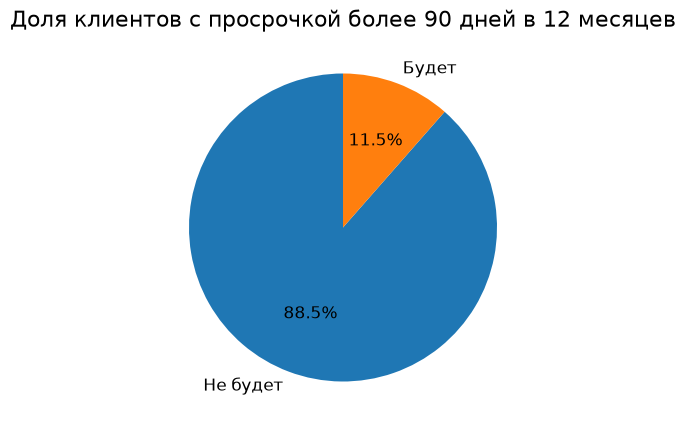

In [36]:
grouped = df.groupby('target')['age'].count().reset_index().sort_values(by = 'age',ascending=False)
grouped.index = ['Не будет' , 'Будет']
grouped['age'] = round(100*grouped['age']/sum(grouped['age']),2)

fig = grouped['age'].plot.pie(figsize = (5,5),autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'color': 'black'})

plt.title('Доля клиентов с просрочкой более 90 дней в 12 месяцев', fontsize=16)
plt.ylabel('')
plt.show()

<span style="font-size: 16px;">**Выводы**</span>

Проведенный исследовательский анализ позволил оценить структуру, качество и особенности подготовленного набора данных. Исходные данные из восьми таблиц были последовательно объединены с учетом временной структуры наблюдений. Целевая переменная сформирована для каждой пары «клиент - месяц»: значение 1 соответствует возникновению просрочки более 90 дней в течение следующих 12 месяцев, значение 0 - ее отсутствию.

Итоговый датафрейм содержит 429 491 наблюдение и 28 признаков за период с января 2013 по ноябрь 2019 года. В данных отсутствуют пропуски и дубликаты. Выбросы и аномалии, не соответствующие предметной области, также не выявлены. В ходе подготовки были сформированы относительные и временные признаки, позволяющие учитывать финансовую нагрузку клиента, структуру расходов и динамику расходов и кредитного рейтинга. Были созданы специальные процедуры, позволяющие собрать восемь датасетов в один и сформировать данные для обучения, валидации, калибровки и тестирования модели.

Целевая переменная имеет выраженный дисбаланс классов: положительный класс составляет около 11,5% наблюдений. Это необходимо учитывать при построении моделей, поэтому на этапе моделирования будут рассмотрены различные методы балансировки классов.

Кроме того, поскольку каждое наблюдение относится к конкретному моменту времени, при разделении данных и кросс-валидации необходимо сохранять временной порядок и исключать использование информации из будущего. Это позволит корректно оценить способность модели прогнозировать будущую просрочку и избежать временной утечки данных.

<a id='p7a'></a>

---

## Моделирование

1. Подготовим обучающую, калибровочную и тестовую выборки (тестовая 12 месяцев, калибровочную из 12 месяцев также разделим на две, одна - для обучения калибратора, а вторая для тестирования калибровки). Кросс-валидация будет осуществляться на трех фолдах.
2. Для категориального признака применим OneHotEncoder в рамках pipeline.
3. Обучим базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели - логистическую регрессию и случайный лес - без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Для каждой из типов моделей с балансировкой выберем лучшую модель.
4. Случайный лес с настройками по умолчанию легко переобучается. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации. Чтобы исправить проблемы модели Random Forest, подберем для неё гиперпараметры с помощью Optuna. Для оптимизации используем метрику `missed defaults rate`.
5. Сравним все полученные модели.
6. Для оценки моделей используем метрики:
   * accuracy, ROC-AUC
   * approval rate,
   * default rate,
   * missed defaults rate,
   * а также вспомогательные технический PR-AUC.
7. Сделаем вывод о работе, проделанной в этом разделе.

---

### Логистическая регрессия

[К Содержимому проекта](#contents)

Сначала выделим выборки для обучения, калибровки и тестирования. А также опишем подпрограммы для расчета метрик у некоторой модели.

In [37]:
# Разделение выборок
mxdt = df.index[-1]
mxdt1 = mxdt - relativedelta(months=11)
df_test = df.loc[mxdt1:].copy()
mxdt1 = mxdt - relativedelta(months=12)
df_train_val_cal = df.loc[:mxdt1]

mxdt = df_train_val_cal.index[-1]
mxdt1 = mxdt - relativedelta(months=11)
df_cal = df_train_val_cal.loc[mxdt1:].copy()
mxdt1 = mxdt - relativedelta(months=12)
df_train_val = df_train_val_cal.loc[:mxdt1].copy()

mxdt = df_cal.index[-1]
mxdt1 = mxdt - relativedelta(months=5)
df_cal_val = df_cal.loc[mxdt1:].copy()
mxdt1 = mxdt - relativedelta(months=6)
df_cal_train = df_cal.loc[:mxdt1].copy()

X_train_val = df_train_val.drop(columns = ['target']).copy()
y_train_val = df_train_val['target']

X_cal = df_cal.drop(columns = ['target']).copy()
y_cal = df_cal['target']

X_test = df_test.drop(columns = ['target']).copy()
y_test = df_test['target']

X_cal_train = df_cal_train.drop(columns = ['target']).copy()
y_cal_train = df_cal_train['target']

X_cal_val = df_cal_val.drop(columns = ['target']).copy()
y_cal_val = df_cal_val['target']

<span style="font-size: 16px;">**Подпрограммы для вычисления бизнесовых метрик и кросс-валидации.**</span>

In [38]:
def approval_rate(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    TN = ((y_true == 0) & (y_pred == 0)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    return float((TN + FN) / y_true.shape[0])

def default_rate(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    TN = ((y_true == 0) & (y_pred == 0)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    return float(FN / (TN + FN))
    
def missed_defaults_rate(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    return float(1.0 - recall_score(y_true, y_pred))

def metrics_dict_calc(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    return {
        'approval_rate' : approval_rate(y_true, y_pred_proba, cutoff),
        'default_rate' : default_rate(y_true, y_pred_proba, cutoff),
        'missed_defaults_rate' : missed_defaults_rate(y_true, y_pred_proba, cutoff),
        'accuracy' : accuracy_score(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_pred_proba),
        'pr_auc' : average_precision_score(y_true, y_pred_proba)
    }

def TimeSeriesCrossVal(model, gtscv, groups, X_train_val, y_train_val, model_name = 'Unknown'):
    met_list = ['approval_rate', 'default_rate', 'missed_defaults_rate', 'accuracy', 'roc_auc', 'pr_auc']
    
    cv_met = {}
    for met in met_list:
        cv_met[f'{met}_tra'] = []
        cv_met[f'{met}_val'] = []
    
    for i, (train_idx, val_idx) in enumerate(gtscv.split(X_train_val, y_train_val, groups=groups)):
        X_train = X_train_val.iloc[train_idx].copy()
        y_train = y_train_val.iloc[train_idx].copy()
        
        X_val = X_train_val.iloc[val_idx].copy()
        y_val = y_train_val.iloc[val_idx].copy()
        
        model.fit(X_train,y_train)
        y_pred_proba = model.predict_proba(X_train)[:,1]
        metrics = metrics_dict_calc(y_train, y_pred_proba)
        for met in met_list:
            cv_met[f'{met}_tra'].append(metrics[met])
        
        y_pred_proba = model.predict_proba(X_val)[:,1]
        metrics = metrics_dict_calc(y_val, y_pred_proba)
        for met in met_list:
            cv_met[f'{met}_val'].append(metrics[met])
    
    cv_met_all = {'model_name': [model_name, model_name], 'fold_name' : ['train', 'val']}
    for met in met_list:
        cv_met_all[met] = []
    
    for suf in ['_tra', '_val']:
        for met in met_list:
            avg = round(pd.Series(cv_met[met + suf]).mean(),3)
            std = round(pd.Series(cv_met[met + suf]).std(),3)
            
            cv_met_all[met].append(f'{avg} ± {std}')
    
    
    return cv_met_all

<span style="font-size: 16px;">**Пайплайн логистической регрессии:**</span>

In [39]:
# Pipeline для категориальных признаков с малым количеством категорий
ohe_l = X_train_val.select_dtypes(include=["str", "object", "category"]).columns.tolist()
ohe_pip = Pipeline([ ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')) ])
# для платформы так ('ohe', OneHotEncoder(sparse=False, handle_unknown='ignore'))

# Pipeline для числовых признаков с масштабированием
num_l = [col for col in X_train_val.select_dtypes(include=["float","int"]).columns 
         if col != 'spendings_sh']
num_pip = Pipeline([ ('standard', StandardScaler()) ])


# ColumnTransformer для всех колонок
line_preprocessor = ColumnTransformer(
    transformers=[('cat_ohe', ohe_pip, ohe_l),
                  ('num_standard', num_pip, num_l) 
                 ])

<span style="font-size: 16px;">**Перебор разных стратегий по борьбе с дисбалансом классов**</span>

In [40]:
# Выделение групп из трайна
miny = min(X_train_val.index).year
groups = (X_train_val.reset_index()['score_date'].dt.year - miny) * 12 + X_train_val.reset_index()['score_date'].dt.month

# Создаем параметры разбиения
cv_args = {
    "test_size": 12,          # валидация - 12 месяцев
#    "train_size": 23,         # train - 23 месяца, только для rolling
    "n_splits": 3,            # это для expanding
    "gap_size": 0,            # без разрыва между train и val
    "shift_size": 12,         # сдвиг между фолдами - 12 месяцев
    "window_type": "expanding"# окно расширяется expanding, альтернатива rolling
}
gtscv = GroupTimeSeriesSplit(**cv_args)

In [41]:
#Pipeline для перебора:
pipelines = {
    'LogReg': Pipeline([('preprocessing', line_preprocessor), 
                        ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_balanced': Pipeline([('preprocessing', line_preprocessor), 
                                 ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000, class_weight='balanced'))]),
    'LogReg_over_1': ImbPipeline([('preprocessing', line_preprocessor),
                                  ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_over_05': ImbPipeline([('preprocessing', line_preprocessor),
                                   ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 0.5)),
                                   ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_over_smote': ImbPipeline([('preprocessing', line_preprocessor),
                                      ('over_smote', SMOTE(random_state=random_state)),
                                      ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_under_1': ImbPipeline([('preprocessing', line_preprocessor),
                                  ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_under_05': ImbPipeline([('preprocessing', line_preprocessor),
                                    ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 0.5)),
                                    ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))])
}

lin_df = pd.DataFrame()
for name, model in pipelines.items():
    pr_df = pd.DataFrame(TimeSeriesCrossVal(model, gtscv, groups, X_train_val, y_train_val, name))
    lin_df = pd.concat([lin_df, pr_df], axis=0, ignore_index=True)

In [42]:
display(lin_df.sort_values(by = ['fold_name', 'missed_defaults_rate']))

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,pr_auc
10,LogReg_under_1,train,0.598 ± 0.014,0.08 ± 0.027,0.246 ± 0.045,0.693 ± 0.017,0.787 ± 0.035,0.412 ± 0.009
2,LogReg_balanced,train,0.599 ± 0.012,0.08 ± 0.028,0.248 ± 0.048,0.693 ± 0.017,0.787 ± 0.035,0.412 ± 0.01
8,LogReg_over_smote,train,0.598 ± 0.013,0.081 ± 0.028,0.249 ± 0.047,0.692 ± 0.017,0.787 ± 0.035,0.414 ± 0.01
4,LogReg_over_1,train,0.6 ± 0.012,0.081 ± 0.028,0.25 ± 0.049,0.694 ± 0.017,0.787 ± 0.035,0.412 ± 0.01
6,LogReg_over_05,train,0.814 ± 0.016,0.133 ± 0.032,0.563 ± 0.071,0.788 ± 0.014,0.786 ± 0.035,0.417 ± 0.008
12,LogReg_under_05,train,0.815 ± 0.018,0.133 ± 0.033,0.565 ± 0.075,0.788 ± 0.014,0.786 ± 0.035,0.417 ± 0.008
0,LogReg,train,0.947 ± 0.003,0.172 ± 0.026,0.856 ± 0.006,0.812 ± 0.025,0.785 ± 0.035,0.42 ± 0.007
11,LogReg_under_1,val,0.709 ± 0.073,0.043 ± 0.017,0.227 ± 0.023,0.779 ± 0.056,0.86 ± 0.041,0.401 ± 0.005
5,LogReg_over_1,val,0.717 ± 0.062,0.045 ± 0.02,0.237 ± 0.028,0.785 ± 0.05,0.86 ± 0.041,0.401 ± 0.005
3,LogReg_balanced,val,0.721 ± 0.054,0.046 ± 0.021,0.242 ± 0.035,0.787 ± 0.045,0.86 ± 0.041,0.401 ± 0.005


Итого согласно требованиям в следующем этапе из линейных будем рассматривать: 
- `LogReg_under_1` - линейная модель с уменьшением количества наблюдений до 1 к 1 с меньшим классом.
- `LogReg` - линейная модель без балансировки классов.

Подобный выбор определяется значением метрики `missed_defaults_rate` на валидационной выборке. Эти модели полярны друг к другу, одна осторожна (`LogReg_under_1`) и часто предупреждает о дефолте там, где его возможно и нет, но при этом достаточно часто находит настоящие дефолты. А `LogReg` редко предупреждает о возможном дефолте клиента.

<a id='p7b'></a>

---

### Случайный лес

[К Содержимому проекта](#contents)

In [43]:
# Pipeline для категориальных признаков с малым количеством категорий
ohe_rf = X_train_val.select_dtypes(include=["str", "object", "category"]).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# для платформы так ('ohe', OneHotEncoder(sparse=False, handle_unknown='ignore'))

# Pipeline для числовых признаков с масштабированием
num_rf = X_train_val.select_dtypes(include=["float","int"]).columns.tolist()
num = StandardScaler()

# ColumnTransformer для всех колонок
rf_preprocessor = ColumnTransformer(
    transformers=[('cat_ohe', ohe, ohe_rf),
                  ('num_standard', num, num_rf)])

In [44]:
#Pipeline для перебора:
pipelines = {
    'RanFor': Pipeline([('preprocessing', rf_preprocessor), 
                        ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_balanced': Pipeline([('preprocessing', rf_preprocessor), 
                                 ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state, class_weight='balanced'))]),
    'RanFor_over_1': ImbPipeline([('preprocessing', rf_preprocessor),
                                  ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_over_05': ImbPipeline([('preprocessing', rf_preprocessor),
                                   ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 0.5)),
                                   ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_over_smote': ImbPipeline([('preprocessing', rf_preprocessor),
                                      ('over_smote', SMOTE(random_state=random_state)),
                                      ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_under_1': ImbPipeline([('preprocessing', rf_preprocessor),
                                  ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_under_05': ImbPipeline([('preprocessing', rf_preprocessor),
                                    ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 0.5)),
                                    ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))])
}

rf_df = pd.DataFrame()
for name, model in pipelines.items():
    pr_df = pd.DataFrame(TimeSeriesCrossVal(model, gtscv, groups, X_train_val, y_train_val, name))
    rf_df = pd.concat([rf_df, pr_df], axis=0, ignore_index=True)

In [45]:
display(rf_df.sort_values(by = ['fold_name', 'missed_defaults_rate']))

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,pr_auc
0,RanFor,train,0.81 ± 0.027,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
2,RanFor_balanced,train,0.81 ± 0.027,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
4,RanFor_over_1,train,0.81 ± 0.027,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
6,RanFor_over_05,train,0.81 ± 0.027,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
8,RanFor_over_smote,train,0.81 ± 0.027,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
10,RanFor_under_1,train,0.609 ± 0.015,0.0 ± 0.0,0.0 ± 0.0,0.799 ± 0.013,0.992 ± 0.0,0.957 ± 0.008
12,RanFor_under_05,train,0.741 ± 0.008,0.0 ± 0.0,0.0 ± 0.0,0.931 ± 0.019,0.998 ± 0.001,0.991 ± 0.005
11,RanFor_under_1,val,0.692 ± 0.048,0.027 ± 0.019,0.13 ± 0.054,0.786 ± 0.037,0.888 ± 0.033,0.45 ± 0.005
9,RanFor_over_smote,val,0.813 ± 0.033,0.063 ± 0.025,0.38 ± 0.033,0.842 ± 0.035,0.887 ± 0.033,0.443 ± 0.008
13,RanFor_under_05,val,0.819 ± 0.017,0.064 ± 0.029,0.386 ± 0.074,0.846 ± 0.028,0.889 ± 0.033,0.461 ± 0.007


Итого согласно требованиям в следующем этапе из моделей случайного леса будем рассматривать: 
- `RanFor_under_1` - модель с уменьшением количества наблюдений до 1 к 1 с меньшим классом.
- `RanFor` - модель без балансировки классов.

Подобный выбор определяется значением метрики `missed_defaults_rate` на валидационной выборке.

---

<span style="font-size: 18px;">**Гиперпараметры для случайного леса**</span>

Определим через `Optuna` оптимальные параметры для работы. 

**Замечание:** диапазоны и значения параметров указаны исходя из других попыток, которые не вошли в итоговую версию. В данной версии указаны диапазоны, которые облегчают и ускоряют поиск нужных параметров за как можно более маленькое время.

In [46]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 40),
        "max_depth": trial.suggest_int("max_depth", 3, 35),
        "max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2', None]),
        "max_samples": trial.suggest_float("max_samples", 0.6, 1.0)
    }
    
    model = Pipeline([("preprocessing", rf_preprocessor), 
                      ("model", RandomForestClassifier(n_jobs=-1, random_state=random_state, **params))])
    
    metrics = []
    for i, (train_idx, val_idx) in enumerate(gtscv.split(X_train_val, y_train_val, groups=groups)):
        X_train = X_train_val.iloc[train_idx].copy()
        y_train = y_train_val.iloc[train_idx].copy()
        
        X_val = X_train_val.iloc[val_idx].copy()
        y_val = y_train_val.iloc[val_idx].copy()
        
        model.fit(X_train,y_train)
        y_pred_proba = model.predict_proba(X_val)[:,1]
        metrics.append(missed_defaults_rate(y_val, y_pred_proba))
    
    return pd.Series(metrics).mean()

sampler = optuna.samplers.TPESampler(seed=random_state)
study_nb = optuna.create_study(direction="minimize", sampler=sampler)
study_nb.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-09-26 12:30:42,290] A new study created in memory with name: no-name-09f8e231-b8d9-4c06-afe5-7e65817fea37


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-26 12:30:45,298] Trial 0 finished with value: 0.7559605098524956 and parameters: {'n_estimators': 21, 'max_depth': 34, 'max_features': 'sqrt', 'max_samples': 0.662397808134481}. Best is trial 0 with value: 0.7559605098524956.
[I 2026-09-26 12:30:47,459] Trial 1 finished with value: 0.7354104025365094 and parameters: {'n_estimators': 11, 'max_depth': 31, 'max_features': 'log2', 'max_samples': 0.9879639408647978}. Best is trial 1 with value: 0.7354104025365094.
[I 2026-09-26 12:31:04,171] Trial 2 finished with value: 0.7726558434210721 and parameters: {'n_estimators': 35, 'max_depth': 10, 'max_features': None, 'max_samples': 0.8099025726528951}. Best is trial 1 with value: 0.7354104025365094.
[I 2026-09-26 12:31:06,845] Trial 3 finished with value: 0.8481698198266644 and parameters: {'n_estimators': 23, 'max_depth': 12, 'max_features': 'sqrt', 'max_samples': 0.7465447373174767}. Best is trial 1 with value: 0.7354104025365094.
[I 2026-09-26 12:31:19,575] Trial 4 finished with v

[I 2026-09-26 12:36:52,653] Trial 33 finished with value: 0.6245874295488655 and parameters: {'n_estimators': 20, 'max_depth': 30, 'max_features': None, 'max_samples': 0.7669797258443656}. Best is trial 14 with value: 0.604030723123323.
[I 2026-09-26 12:37:10,318] Trial 34 finished with value: 0.6563201203599309 and parameters: {'n_estimators': 23, 'max_depth': 31, 'max_features': None, 'max_samples': 0.9803151344834615}. Best is trial 14 with value: 0.604030723123323.
[I 2026-09-26 12:37:29,276] Trial 35 finished with value: 0.6240290437801895 and parameters: {'n_estimators': 26, 'max_depth': 35, 'max_features': None, 'max_samples': 0.9824031610104484}. Best is trial 14 with value: 0.604030723123323.
[I 2026-09-26 12:37:36,993] Trial 36 finished with value: 0.5837630355070876 and parameters: {'n_estimators': 10, 'max_depth': 25, 'max_features': None, 'max_samples': 0.7564715030813347}. Best is trial 36 with value: 0.5837630355070876.
[I 2026-09-26 12:37:51,148] Trial 37 finished with 

Лучшие гиперпараметры: {'n_estimators': 10, 'max_depth': 31, 'max_features': None, 'max_samples': 0.6423908248220523}
Лучшее среднее значение missed_defaults_rate на кросс-валидации: 0.575085500684439


C:\Users\EA\AppData\Local\Temp\ipykernel_4848\2548095883.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_nb)
C:\Users\EA\AppData\Local\Temp\ipykernel_4848\2548095883.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_nb)


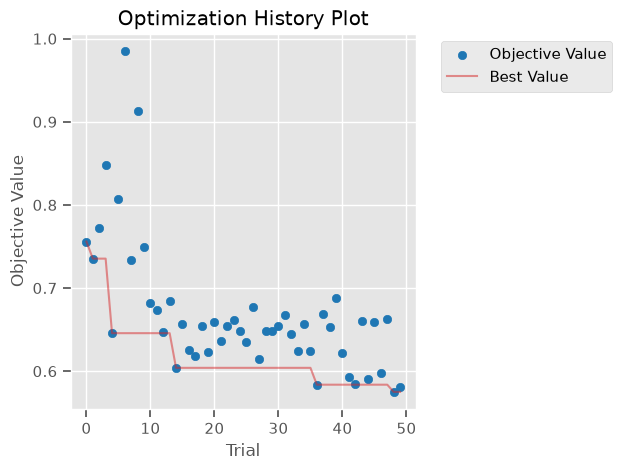

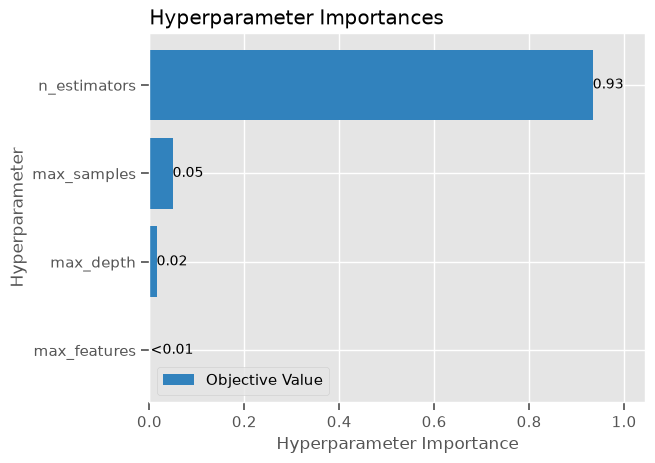

In [47]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_nb.best_params)
print("Лучшее среднее значение missed_defaults_rate на кросс-валидации:", study_nb.best_value)

plot_optimization_history(study_nb)
plot_param_importances(study_nb)
plt.show()

Далее подберем для модели, учитывающей баланс классов.

In [48]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 20, 50),
        "max_depth": trial.suggest_int("max_depth", 3, 25),
        "max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2', None]),
        "max_samples": trial.suggest_float("max_samples", 0.55, 0.9)
    }
    
    model = ImbPipeline([('preprocessing', rf_preprocessor),
                         ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                         ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state, **params))])
    metrics = []
    for i, (train_idx, val_idx) in enumerate(gtscv.split(X_train_val, y_train_val, groups=groups)):
        X_train = X_train_val.iloc[train_idx].copy()
        y_train = y_train_val.iloc[train_idx].copy()
        
        X_val = X_train_val.iloc[val_idx].copy()
        y_val = y_train_val.iloc[val_idx].copy()
        
        model.fit(X_train,y_train)
        y_pred_proba = model.predict_proba(X_val)[:,1]
        metrics.append(missed_defaults_rate(y_val, y_pred_proba))
    
    return pd.Series(metrics).mean()

sampler = optuna.samplers.TPESampler(seed=random_state)
study_b = optuna.create_study(direction="minimize", sampler=sampler)
study_b.optimize(objective, n_trials=300, show_progress_bar=True)

[I 2026-09-26 12:39:29,030] A new study created in memory with name: no-name-ed3da701-a257-4216-875b-d7815b08dc25


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-09-26 12:39:30,439] Trial 0 finished with value: 0.15057439554907645 and parameters: {'n_estimators': 31, 'max_depth': 24, 'max_features': 'sqrt', 'max_samples': 0.604598082117671}. Best is trial 0 with value: 0.15057439554907645.
[I 2026-09-26 12:39:31,767] Trial 1 finished with value: 0.14879194996845643 and parameters: {'n_estimators': 21, 'max_depth': 22, 'max_features': 'log2', 'max_samples': 0.889468448256698}. Best is trial 1 with value: 0.14879194996845643.
[I 2026-09-26 12:39:36,089] Trial 2 finished with value: 0.14910544851987015 and parameters: {'n_estimators': 45, 'max_depth': 7, 'max_features': None, 'max_samples': 0.7336647510712833}. Best is trial 1 with value: 0.14879194996845643.
[I 2026-09-26 12:39:37,319] Trial 3 finished with value: 0.10081234144408187 and parameters: {'n_estimators': 33, 'max_depth': 9, 'max_features': 'sqrt', 'max_samples': 0.6782266451527921}. Best is trial 3 with value: 0.10081234144408187.
[I 2026-09-26 12:39:42,568] Trial 4 finished w

[I 2026-09-26 12:40:20,226] Trial 33 finished with value: 0.09013409459151529 and parameters: {'n_estimators': 31, 'max_depth': 4, 'max_features': 'sqrt', 'max_samples': 0.711184523501021}. Best is trial 24 with value: 0.074994369285254.
[I 2026-09-26 12:40:21,342] Trial 34 finished with value: 0.12706083522898337 and parameters: {'n_estimators': 20, 'max_depth': 12, 'max_features': 'sqrt', 'max_samples': 0.7121357324805665}. Best is trial 24 with value: 0.074994369285254.
[I 2026-09-26 12:40:22,300] Trial 35 finished with value: 0.08103871141555168 and parameters: {'n_estimators': 31, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.6559747805403897}. Best is trial 24 with value: 0.074994369285254.
[I 2026-09-26 12:40:23,692] Trial 36 finished with value: 0.10155383031983756 and parameters: {'n_estimators': 38, 'max_depth': 9, 'max_features': 'sqrt', 'max_samples': 0.8096492517583377}. Best is trial 24 with value: 0.074994369285254.
[I 2026-09-26 12:40:24,693] Trial 37 finishe

[I 2026-09-26 12:40:56,020] Trial 66 finished with value: 0.10121866049834267 and parameters: {'n_estimators': 31, 'max_depth': 9, 'max_features': 'sqrt', 'max_samples': 0.5896678682494506}. Best is trial 24 with value: 0.074994369285254.
[I 2026-09-26 12:40:57,148] Trial 67 finished with value: 0.09423242267625842 and parameters: {'n_estimators': 32, 'max_depth': 8, 'max_features': 'sqrt', 'max_samples': 0.703654806298938}. Best is trial 24 with value: 0.074994369285254.
[I 2026-09-26 12:40:58,144] Trial 68 finished with value: 0.0801642665066666 and parameters: {'n_estimators': 28, 'max_depth': 6, 'max_features': 'sqrt', 'max_samples': 0.5970704903337866}. Best is trial 24 with value: 0.074994369285254.
[I 2026-09-26 12:40:59,213] Trial 69 finished with value: 0.07393927444043058 and parameters: {'n_estimators': 39, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7483172233322777}. Best is trial 69 with value: 0.07393927444043058.
[I 2026-09-26 12:41:00,476] Trial 70 finishe

...

[I 2026-09-26 12:42:42,667] Trial 165 finished with value: 0.07205388027828907 and parameters: {'n_estimators': 20, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.8285216772216697}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:42:43,566] Trial 166 finished with value: 0.09348853319802335 and parameters: {'n_estimators': 21, 'max_depth': 4, 'max_features': 'sqrt', 'max_samples': 0.8341585200732559}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:42:44,442] Trial 167 finished with value: 0.07048754335502434 and parameters: {'n_estimators': 22, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7323131183160737}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:42:45,328] Trial 168 finished with value: 0.08713488962819975 and parameters: {'n_estimators': 25, 'max_depth': 4, 'max_features': 'sqrt', 'max_samples': 0.7322240014118402}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:42:46,165] 

[I 2026-09-26 12:43:14,404] Trial 198 finished with value: 0.06972878563813749 and parameters: {'n_estimators': 22, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7327218892456026}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:15,298] Trial 199 finished with value: 0.06903212157487759 and parameters: {'n_estimators': 21, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7359383336771653}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:16,226] Trial 200 finished with value: 0.07028850820041643 and parameters: {'n_estimators': 22, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7775887455229971}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:17,245] Trial 201 finished with value: 0.08762986643317676 and parameters: {'n_estimators': 20, 'max_depth': 7, 'max_features': 'sqrt', 'max_samples': 0.7680367033966513}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:18,080] 

[I 2026-09-26 12:43:49,989] Trial 231 finished with value: 0.08667594914102539 and parameters: {'n_estimators': 21, 'max_depth': 4, 'max_features': 'sqrt', 'max_samples': 0.7356515286041309}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:51,002] Trial 232 finished with value: 0.07016928345581101 and parameters: {'n_estimators': 20, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.8085735234040413}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:51,972] Trial 233 finished with value: 0.07504508630685743 and parameters: {'n_estimators': 22, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.6701497135065074}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:52,927] Trial 234 finished with value: 0.06919901575984388 and parameters: {'n_estimators': 20, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.8102233763333514}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:43:55,278] 

[I 2026-09-26 12:44:22,695] Trial 264 finished with value: 0.09546000335807898 and parameters: {'n_estimators': 23, 'max_depth': 4, 'max_features': 'sqrt', 'max_samples': 0.7988904499377525}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:44:23,726] Trial 265 finished with value: 0.06801044503204541 and parameters: {'n_estimators': 21, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.8061446519700565}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:44:24,848] Trial 266 finished with value: 0.08525206662494922 and parameters: {'n_estimators': 22, 'max_depth': 5, 'max_features': 'log2', 'max_samples': 0.8194876421174728}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:44:25,718] Trial 267 finished with value: 0.0690081983723196 and parameters: {'n_estimators': 20, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7350172549880121}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:44:26,791] T

[I 2026-09-26 12:44:58,184] Trial 297 finished with value: 0.08513940303599317 and parameters: {'n_estimators': 20, 'max_depth': 4, 'max_features': 'sqrt', 'max_samples': 0.7326605508431718}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:44:58,993] Trial 298 finished with value: 0.08851930816237434 and parameters: {'n_estimators': 20, 'max_depth': 4, 'max_features': 'sqrt', 'max_samples': 0.7723179603244981}. Best is trial 162 with value: 0.06481474230467328.
[I 2026-09-26 12:44:59,845] Trial 299 finished with value: 0.07076059524898319 and parameters: {'n_estimators': 21, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7252209932229619}. Best is trial 162 with value: 0.06481474230467328.


Лучшие гиперпараметры: {'n_estimators': 21, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7907756402235673}
Лучшее среднее значение missed_defaults_rate на кросс-валидации: 0.06481474230467328


C:\Users\EA\AppData\Local\Temp\ipykernel_4848\733731771.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_b)
C:\Users\EA\AppData\Local\Temp\ipykernel_4848\733731771.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_b)


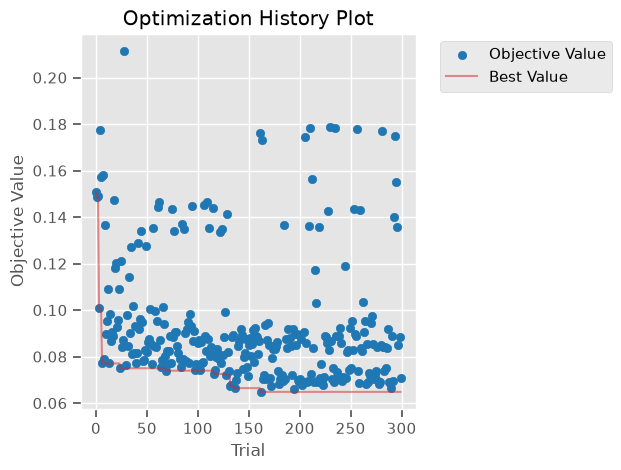

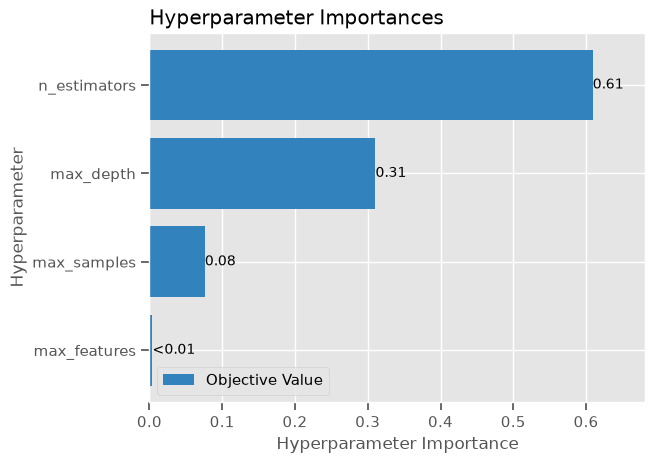

In [49]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_b.best_params)
print("Лучшее среднее значение missed_defaults_rate на кросс-валидации:", study_b.best_value)

plot_optimization_history(study_b)
plot_param_importances(study_b)
plt.show()

<a id='p7c'></a>

---

### Сравнение и выводы по моделям

[К Содержимому проекта](#contents)

Рассчитаем метрики на калибровочной выборке для всех четырех моделей. Дополнительно выведем метрики на тренировочной выборке для оценки переобучения.

In [50]:
def calculate_ece(y_true, y_pred_prob, n_bins=10):
    # Создаем границы бинов от 0 до 1, например, [0.0, 0.1, ..., 1.0].
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0 
    n = len(y_true)
    # Итерируемся по каждому бину.
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Создаем логическую маску для отбора примеров, которые попадают в текущий бин.
        # Последний бин (i == n_bins - 1) включает правую границу, чтобы захватить
        # вероятность 1.0, остальные - нет.
        if i == n_bins - 1:
            mask = (y_pred_prob >= bin_lower) & (y_pred_prob <= bin_upper)
        else:
            mask = (y_pred_prob >= bin_lower) & (y_pred_prob < bin_upper)
        # Проверяем, есть ли в текущем бине хотя бы один пример.
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            # Вычисляем среднюю предсказанную уверенность (confidence) для бина.
            bin_conf = np.mean(y_pred_prob[mask])
            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask])
            # Вычисляем вклад текущего бина в общую ошибку.
            # Это абсолютная разница, умноженная на количество примеров в бине.
            contribution = np.abs(bin_conf - bin_acc) * bin_size
            ece += contribution
    
    return ece / n

def calculate_mce(y_true, y_prob, n_bins=10):
    # Создаем границы бинов от 0 до 1, например, [0.0, 0.1, ..., 1.0].
    bins = np.linspace(0, 1, n_bins + 1)
    # Инициализируем максимальную ошибку
    max_error = -1
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Последний бин включает верхнюю границу (1.0).
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        # Продолжаем, только если в бине есть хотя бы один объект.
        if np.sum(mask) > 0:
            # Вычисляем среднюю уверенность модели для этого бина.
            bin_conf = np.mean(y_prob[mask])
            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask])
            # Вычисляем абсолютную разницу между точностью и уверенностью.
            diff = np.abs(bin_conf - bin_acc)
            # Обновляем максимальную ошибку, если текущая разница больше.
            max_error = max(max_error, diff)
            
    return max_error

def CalcMetricsFinal(y_true, y_pred_proba, cutoff = 0.5, fold_name = 'Unknown', model_name = 'Unknown'):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    return {
        'model_name' : model_name,
        'fold_name' : fold_name,
        'approval_rate' : approval_rate(y_true, y_pred_proba, cutoff),
        'default_rate' : default_rate(y_true, y_pred_proba, cutoff),
        'missed_defaults_rate' : missed_defaults_rate(y_true, y_pred_proba, cutoff),
        'brier_score_loss': brier_score_loss(y_true, y_pred),
        'ECE': calculate_ece(y_true, y_pred_proba, n_bins=20),
        'MCE': calculate_mce(y_true, y_pred_proba, n_bins=20),
        'accuracy' : accuracy_score(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_pred_proba),
        'pr_auc' : average_precision_score(y_true, y_pred_proba),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred)
    }

In [51]:
lr_simple = Pipeline([('preprocessing', line_preprocessor), 
                      ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))])
lr_under1 = ImbPipeline([('preprocessing', line_preprocessor),
                         ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                         ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))])

rf_simple = Pipeline([("preprocessing", rf_preprocessor), 
                      ("model", RandomForestClassifier(n_jobs=-1, random_state=random_state, **study_nb.best_params))])
rf_under1 = ImbPipeline([('preprocessing', rf_preprocessor),
                         ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 1)),
                         ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state, **study_b.best_params))])

res_l = []
lr_simple.fit(X_train_val,y_train_val)
lr_under1.fit(X_train_val,y_train_val)
rf_simple.fit(X_train_val,y_train_val)
rf_under1.fit(X_train_val,y_train_val)

y_pred_proba = lr_simple.predict_proba(X_cal)[:,1]
res_l.append(CalcMetricsFinal(y_cal, y_pred_proba, cutoff = 0.5, fold_name = 'Cal', model_name = 'LogReg'))
y_pred_proba = lr_under1.predict_proba(X_cal)[:,1]
res_l.append(CalcMetricsFinal(y_cal, y_pred_proba, cutoff = 0.5, fold_name = 'Cal', model_name = 'LogReg_under_1'))
y_pred_proba = rf_simple.predict_proba(X_cal)[:,1]
res_l.append(CalcMetricsFinal(y_cal, y_pred_proba, cutoff = 0.5, fold_name = 'Cal', model_name = 'RanFor_non_balanced'))
y_pred_proba = rf_under1.predict_proba(X_cal)[:,1]
res_l.append(CalcMetricsFinal(y_cal, y_pred_proba, cutoff = 0.5, fold_name = 'Cal', model_name = 'RanFor_undersampled_1'))

y_pred_proba = lr_simple.predict_proba(X_train_val)[:,1]
res_l.append(CalcMetricsFinal(y_train_val, y_pred_proba, cutoff = 0.5, fold_name = 'Train', model_name = 'LogReg'))
y_pred_proba = lr_under1.predict_proba(X_train_val)[:,1]
res_l.append(CalcMetricsFinal(y_train_val, y_pred_proba, cutoff = 0.5, fold_name = 'Train', model_name = 'LogReg_under_1'))
y_pred_proba = rf_simple.predict_proba(X_train_val)[:,1]
res_l.append(CalcMetricsFinal(y_train_val, y_pred_proba, cutoff = 0.5, fold_name = 'Train', model_name = 'RanFor_non_balanced'))
y_pred_proba = rf_under1.predict_proba(X_train_val)[:,1]
res_l.append(CalcMetricsFinal(y_train_val, y_pred_proba, cutoff = 0.5, fold_name = 'Train', model_name = 'RanFor_undersampled_1'))

res_df = pd.DataFrame(res_l)

In [52]:
display(res_df.sort_values(by = ['fold_name', 'missed_defaults_rate']))

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
3,RanFor_undersampled_1,Cal,0.685521,0.002599,0.015858,0.205670,0.127435,0.383060,0.794330,0.909171,0.464708,0.351664,0.984142
1,LogReg_under_1,Cal,0.751519,0.020841,0.139377,0.167432,0.151386,0.496325,0.832568,0.907157,0.428703,0.389208,0.860623
2,RanFor_non_balanced,Cal,0.902774,0.072143,0.579576,0.115110,0.029830,0.321943,0.884890,0.899506,0.453833,0.485922,0.420424
0,LogReg,Cal,0.956910,0.095266,0.811234,0.113039,0.039794,0.352791,0.886961,0.908885,0.451995,0.492277,0.188766
7,RanFor_undersampled_1,Train,0.501213,0.003508,0.012374,0.360227,0.223704,0.435229,0.639773,0.862787,0.442570,0.281318,0.987626
6,RanFor_non_balanced,Train,0.861115,0.009257,0.056106,0.012752,0.060354,0.356565,0.987248,0.998340,0.988048,0.965576,0.943894
5,LogReg_under_1,Train,0.634769,0.036322,0.162280,0.269268,0.220247,0.502207,0.730732,0.847602,0.394770,0.325874,0.837720
4,LogReg,Train,0.955136,0.125800,0.845717,0.143100,0.026803,0.312525,0.856900,0.846081,0.409105,0.488579,0.154283


<span style="font-size: 16px;">**Выводы**</span>

1. В итоговой версии сравнивались четыре модели:
    - `LogReg` и `LogReg_under_1`: первая модель обычная логистическая регрессия на исходном наборе строк, а вторая модель со случайным уменьшением выборки и выравниванием классов 1 к 1.
    - `RanFor_non_balanced` и `RanFor_undersampled_1`: модель случайного леса без балансировки и с балансировкой классов.
2. Наблюдается некоторая поляризация результатов или мы обеспечиваем высокий `approval_rate`, но при этом достаточно часто пропускаем будущие просрочки (`missed_defaults_rate`). Этот результат обеспечивают модели `RanFor_non_balanced` и `LogReg` ( у моделей `approval_rate` около 90% и 96% соответственно, и `missed_defaults_rate` около 58% и 81%). Такого рода модели из-за дисбаланса классов (примерно 1:9) чаще предсказывают `0` (отсутствие просрочки), что обеспечивает столь высокий `approval_rate`, но при этом пропускают. Однако, когда они его предсказывают, то бывают достаточно часто правы. При этом стоит отметить переобучение модели `RanFor_non_balanced` даже с подборкой гиперпараметров. Она почти идеально запомнила тестовую выборку, но на калибровочной сталкивается с заметным падением качества.
3. Альтернативные результаты формируют модели с балансировкой классов - `RanFor_undersampled_1` и `LogReg_under_1`. Они имеют относительно высокий `approval_rate` (около 69% и 75%), но при этом редко пропускают просрочки у клиентов (`missed_defaults_rate` около 1.6% и 14%). Такого рода модели чаще предсказывают положительный класс - просрочку, что приводит к сильному снижению `missed_defaults_rate` по сравнению с моделями без балансировки классов. Уменьшение количества экземпляров класса `0` привело к тому, что модели стали чаще предсказывать класс `1`. Кроме того, скорость обучения и расчетов значительно повысилась, по сравнению с моделями, обученными на полной выборке.
4. Выигрышными по бизнес-метрикам в обоих случаях являются модели случайного леса, что говорит о сложном, нелинейном характере зависимости целевой переменной от предлагаемых методов решения. 
5. `RanFor_undersampled_1` уже сейчас проходит по показателям для внедрения: `approval rate` — не менее 65%; `default rate` — не более 2%; `missed defaults rate` — не более 4%. Сама модель не демонстрирует ярко выраженных признаков переобучения. Однако, калибровка вероятностей и подбор порога все же рекомендуется, т.к. данные действия могут сделать показатели модели ещё лучше (особенно бизнес-метрики).

<a id='p8'></a>

---

## Калибровка модели и пересчёт результатов

* Проведем калибровку лучшей версии модели. Используем отдельную калибровочную выборку.
* Используем метод, подходящий для случайного леса.
* Построим график калибровки.
* Сделаем вывод, оценим результаты с помощью коэффициента Бриера, ECE, MCE.

[К Содержимому проекта](#contents)

In [53]:
def calibration_curve_plotter(y_true, y_prob_1, y_prob_2 = None, label_list = ['Random Forest'], n_bins=10):
    plt.figure(figsize=(10,10))
    
    prob_true, prob_pred = calibration_curve(y_true, y_prob_1, n_bins=n_bins, strategy='uniform')
    CalibrationDisplay(prob_true, prob_pred, y_true).plot( ax=plt.gca(), label=label_list[0], color='blue')
    
    if y_prob_2 is not None:
        prob_true, prob_pred = calibration_curve(y_true, y_prob_2, n_bins=n_bins, strategy='uniform')
        CalibrationDisplay(prob_true, prob_pred, y_true).plot( ax=plt.gca(), label=label_list[1], color='red')
    
    plt.title("Диаграмма калибровки")
    plt.xlabel("Средняя предсказанная вероятность")
    plt.ylabel("Фактическая доля положительных исходов")
    plt.legend()
    plt.grid(True)
    plt.show()

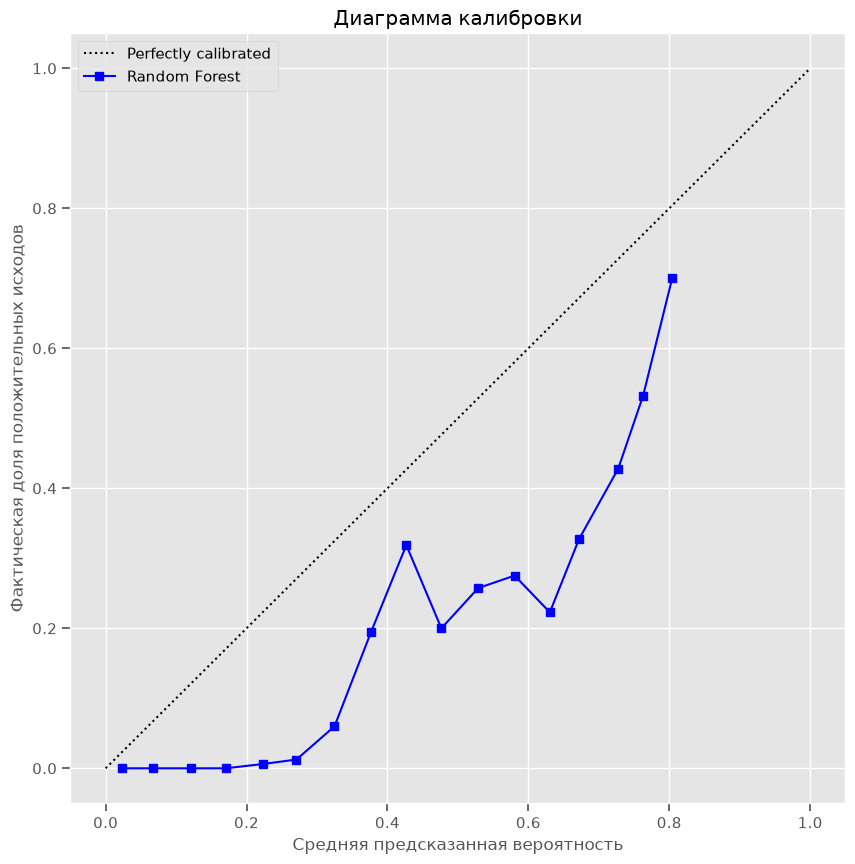

In [54]:
try:
    final_model = FrozenEstimator(rf_under1)
except Exception:
    final_model = rf_under1

y_pred_proba = final_model.predict_proba(X_cal_val)[:, 1]
calibration_curve_plotter(y_cal_val, y_pred_proba, n_bins = 20)

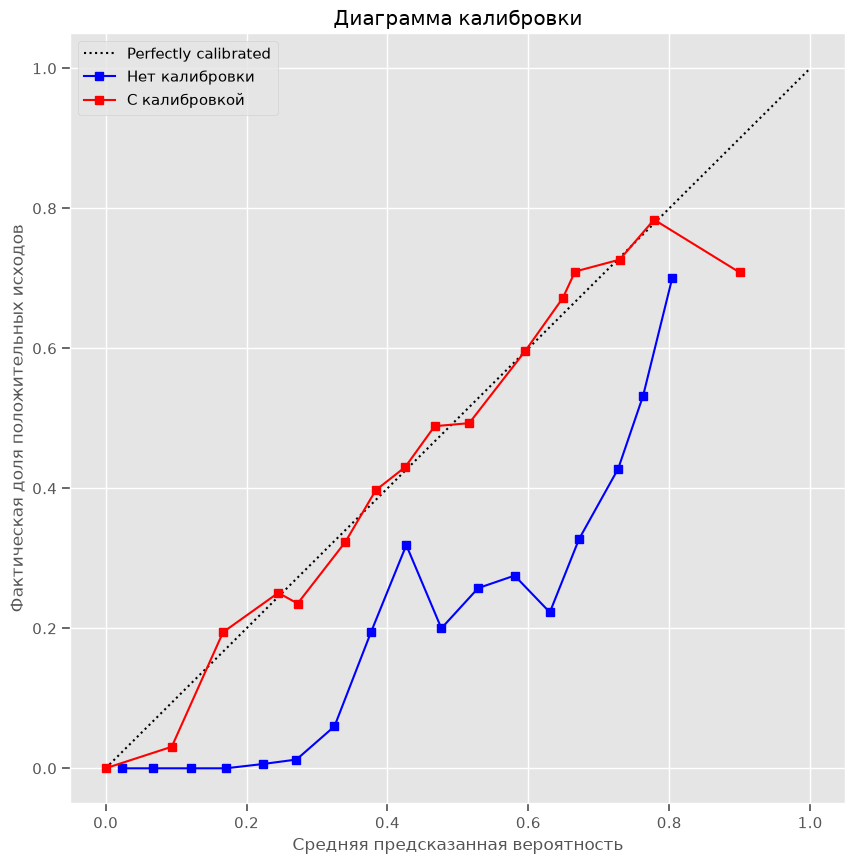

In [55]:
calibrated_final_model = CalibratedClassifierCV(estimator=final_model, method='isotonic' )
calibrated_final_model.fit(X_cal_train, y_cal_train)

y_pred_proba_cal = calibrated_final_model.predict_proba(X_cal_val)[:, 1]
calibration_curve_plotter(y_cal_val, y_pred_proba, y_pred_proba_cal, label_list = ['Нет калибровки', 'С калибровкой'], n_bins=20)

In [56]:
pd.DataFrame([CalcMetricsFinal(y_cal_val, y_pred_proba, cutoff = 0.5, fold_name = 'Cal_Val', model_name = 'RanFor_non_cal')
              ,CalcMetricsFinal(y_cal_val, y_pred_proba_cal, cutoff = 0.5, fold_name = 'Cal_Val', model_name = 'RanFor_cal')
             ])

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,RanFor_non_cal,Cal_Val,0.701508,0.00162,0.010532,0.192872,0.123025,0.407621,0.807128,0.918400,0.481274,0.357652,0.989468
1,RanFor_cal,Cal_Val,0.984628,0.09982,0.910954,0.104050,0.006454,0.191667,0.895950,0.918637,0.470620,0.625000,0.089046


<span style="font-size: 16px;">**Выводы**</span>

1. Модель для калибровки демонстрирует завышенную уверенность в своих результатах на всем диапазоне вероятностей (калибровочная линия находится под диагональю). Калибровка помогла выровнять вероятности модели и сделать их более близким к реальным, хотя на некоторых диапазонах модель остается слишком уверенной (вероятности от 0.7 до 1). 
2. Калибровка помогала значительно снизить `brier_score_loss`, `MCE` (почти в 2 раза), `ECE` (около 20 раз). Разница между `MCE` и `ECE` большая, что сигнализирует о том, что предсказанные вероятности иногда достаточно сильно отличаются от реальных.
3. Калибровка изменила тип модели, ранее она имела низкое значение `missed_defaults_rate` и относительно небольшое значение `approval_rate`. После калибровки модель заметно реже предсказывает дефолты (класс 1), что влечет сильной рост `approval_rate`, но и рост `missed_defaults_rate`. В таком виде модель не может быть рекомендована к внедрению, т.к. не соответствует бизнес-требованиям. Однако, подбор порога поможет понизить `missed_defaults_rate` до приемлемых величин.

<a id='p9'></a>

---

## Поиск порога решения

1. Используем откалиброванную модель и калибровочную выборку, найдем порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate - не менее 65%;
    * default rate - не более 2%;
    * missed defaults rate - не более 4%.
2. Сделаем вывод о достигнутых в этом разделе результатах.

[К Содержимому проекта](#contents)

In [57]:
res_l = []
for cutoff in [0.1, 0.2, 0.23, 0.25, 0.3, 0.4, 0.5]:
    dct = {'cutoff' : cutoff}
    dct = dct | CalcMetricsFinal(y_cal_val, y_pred_proba_cal, cutoff = cutoff, fold_name = 'Cal', model_name = 'RanFor_cal')
    res_l.append(dct)

pd.DataFrame(res_l)

,cutoff,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,0.10,RanFor_cal,Cal,0.696942,0.000119,0.000766,0.195331,0.006454,0.191667,0.804669,0.918637,0.47062,0.355740,0.999234
1,0.20,RanFor_cal,Cal,0.697686,0.000326,0.002106,0.194876,0.006454,0.191667,0.805124,0.918637,0.47062,0.356137,0.997894
2,0.23,RanFor_cal,Cal,0.697686,0.000326,0.002106,0.194876,0.006454,0.191667,0.805124,0.918637,0.47062,0.356137,0.997894
3,0.25,RanFor_cal,Cal,0.713512,0.005878,0.038874,0.186983,0.006454,0.191667,0.813017,0.918637,0.47062,0.361965,0.961126
4,0.30,RanFor_cal,Cal,0.818740,0.035380,0.268480,0.131302,0.006454,0.191667,0.868698,0.918637,0.47062,0.435427,0.731520
5,0.40,RanFor_cal,Cal,0.902149,0.068340,0.571429,0.113264,0.006454,0.191667,0.886736,0.918637,0.47062,0.472551,0.428571
6,0.50,RanFor_cal,Cal,0.984628,0.099820,0.910954,0.104050,0.006454,0.191667,0.895950,0.918637,0.47062,0.625000,0.089046


<span style="font-size: 16px;">**Выводы**</span>

Подбор порога помог достигнуть требуемых по ТЗ показателей. Его оптимальное значение 0.23. При таких значениях:
* `missed_defaults_rate` $\approx$ 0.2% < 4%
* `default_rate` $\approx$ 0.03% < 2%
* `approval_rate` $\approx$ 70% > 65%

Такое снижение порога ведет к тому, что модель более охотно говорить, что у человека будет дефолт в будущем.

<a id='p10'></a>

---

## Анализ матрицы ошибок

1. Оценим стабильность модели на тестовых данных. Для этого построим:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
2. Сделаем вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
3. Сделаем вывод о стабильности модели.

[К Содержимому проекта](#contents)

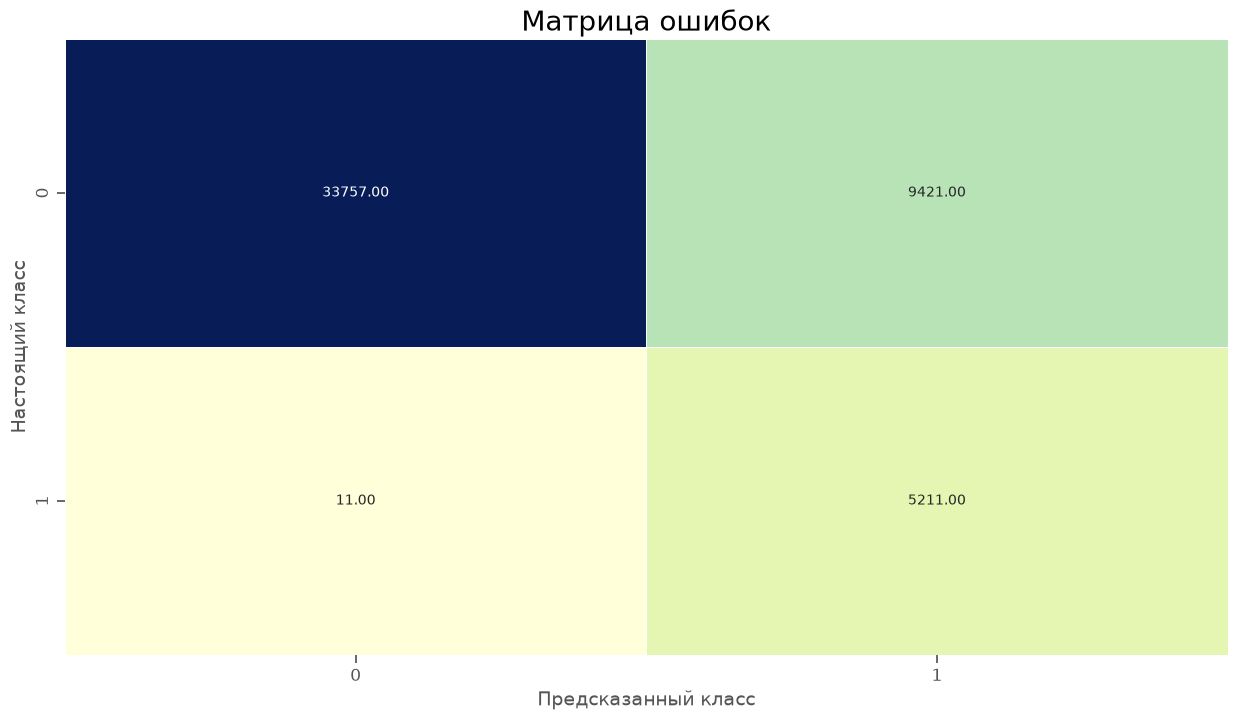

In [58]:
cutoff = 0.23
y_pred_proba_cal = calibrated_final_model.predict_proba(X_cal_val)[:, 1]
y_pred_proba_test = calibrated_final_model.predict_proba(X_test)[:, 1]

y_pred_cal = (y_pred_proba_cal >= cutoff).astype(int)
y_pred_test = (y_pred_proba_test >= cutoff).astype(int)

cm = confusion_matrix(y_cal_val, y_pred_cal)
fig, ax = plt.subplots(figsize=(15,8))
fig = sns.heatmap(cm, 
                annot=True,     # Отображаем численные значения в ячейках карты
                fmt='.2f',      # Форматируем значения корреляции: два знака после точки
                cmap='YlGnBu',  # Устанавливаем цветовую гамму от красного (макс. значение) к синему
                linewidths=0.5, # Форматируем линию между ячейками карты
                cbar=False,     # Отключаем цветовую шкалу
                annot_kws={'size': 10}
                )
plt.title('Матрица ошибок', fontsize=20)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.ylabel('Настоящий класс', fontsize=14)
fig.tick_params(axis='both', labelsize=12)
plt.show()

In [59]:
print(classification_report(y_test, y_pred_test, digits=2))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95     97461
           1       0.35      0.97      0.52      5662

    accuracy                           0.90    103123
   macro avg       0.68      0.94      0.73    103123
weighted avg       0.96      0.90      0.92    103123



In [60]:
pd.DataFrame([CalcMetricsFinal(y_test, y_pred_proba_test, cutoff = cutoff, fold_name = 'Test', model_name = 'RanFor_cal')])

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,RanFor_cal,Test,0.849316,0.001701,0.026316,0.098669,0.00489,0.393939,0.901331,0.948254,0.437106,0.354785,0.973684


<span style="font-size: 16px;">**Выводы**</span>

Построив матрицу ошибок на калибровочной выборке заметна основная проблема модели - она достаточно часто осторожничает и показывает дефолт для человека, у которого дефолта не будет в ближайшие 12 месяцев. При этом она крайне редко пропускает настоящие дефолты (11 штук пропущено из 5222). Это достаточно серьезное преимущество модели. 

На тесте модель сохраняет качество и проходит по ТЗ метрикам. `approval_rate` вырос до 85%, а `missed_defaults_rate` и `default_rate` остались в рамках требуемых показателей. Рассматривая отчет о результатах модели можно заметить, что количество пропорции на тесте по количеству дефолтов изменились. На калибровочной выборке отношение было примерно 1:9, а на тесте - 1:17. Что означает снижение количества дефолтов в последнее время по данным для тестирования и изменения распределения по сравнению с тренировочной, калибровочной выборке и тестом. Тем не менее, в условиях ухудшения дисбаланса классов модель демонстрирует высокое качество, что говорит о возможности ее использования в дальнейшем.

<a id='p11'></a>

---

## Фиксирование итоговой модели

Опишим лучшую модель и найденный порог классификации. Сохраним найденную модель.

[К Содержимому проекта](#contents)

In [61]:
try:
    joblib.dump(calibrated_final_model, '../models/Final_model.joblib')
except Exception:
    joblib.dump(calibrated_final_model, 'Final_model.joblib')

try:
    loaded_best = joblib.load('./../models/Final_model.joblib')
except Exception:
    loaded_best = joblib.load('Final_model.joblib')

pd.DataFrame([CalcMetricsFinal(y_test, y_pred_proba_test, cutoff = cutoff, fold_name = 'Test', model_name = 'loaded_model')])

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,loaded_model,Test,0.849316,0.001701,0.026316,0.098669,0.00489,0.393939,0.901331,0.948254,0.437106,0.354785,0.973684


<span style="font-size: 16px;">**Выводы**</span>

Финальная модель была сохранена вместе с процедурами, готовившими данные для нее. Основные выводы были расписаны чуть выше, по результатам оценки отчета на тесте.

<a id='p12'></a>

---

## Анализ важности признаков

1. Проведем анализ важности признаков найденной модели на полных тренировочных данных.
2. Сделаем вывод о силе влияния признаков на дефолт.

[К Содержимому проекта](#contents)

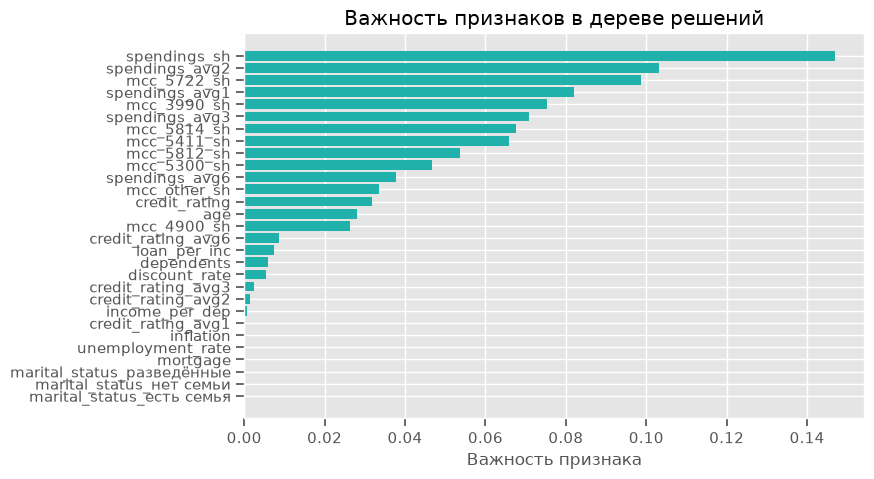

In [62]:
all_feature_name = rf_preprocessor['cat_ohe'].get_feature_names_out(ohe_rf).tolist() + num_rf

# Получение и сортировка по возрастанию важности признаков
importances = pd.Series(final_model['model'].feature_importances_, index=all_feature_name)
importances = importances.sort_values(ascending=True)

# Визуализация
plt.figure(figsize=(8, 5))
plt.barh(importances.index, importances.values, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.show()

<span style="font-size: 16px;">**Выводы**</span>

При оценке важности признаков стоит напомнить, что все расходы измеряются в долях дохода на одного человека в семье на момент получения кредита в банке. В абсолютных значениях хранится только значение самого дохода (`income_per_dep`). Наиболее значимым признакам для модели являются расходы за предыдущий месяц. Другие важные признаки - расходы в предыдущим месяцам по отдельным категориям, а также средние расходы за последние 2, 1, 3, 6 месяцев. Неважными для модели является семейный статус человека, наличие или отсутствие ипотеки у него (в целом логично, т.к. по данным ипотека и есть кредит) и макропоказатель - процент безработного населения. Также слабое влияние оказывает инфляция в предыдущий месяц.

<a id='p13'></a>

---

## Выводы по проекту

[К Содержимому проекта](#contents)


<span style="font-size: 18px;">1. Цель и задачи исследования</span>

Цель проекта - разработать модель поведенческого кредитного скоринга, которая по информации, доступной на момент оценки клиента, прогнозирует возникновение просрочки более 90 дней в течение следующих 12 месяцев. В качестве основных бизнес-ограничений использовались `approval rate` не менее 65%, `default rate` не более 2% и `missed defaults rate` не более 4%.

В рамках проекта проведены исследовательский анализ данных, объединение восьми исходных таблиц, формирование целевой переменной и новых признаков, сравнение моделей логистической регрессии и случайного леса, балансировка классов, подбор гиперпараметров, калибровка вероятностей и оптимизация порога классификации.

<span style="font-size: 18px;">2. Подготовка данных и выборок</span>
- После объединения и обработки данных итоговый датасет содержит 429 491 наблюдение и 28 признаков за период с января 2013 по ноябрь 2019 года.
- Пропуски, дубликаты, выбросы и аномалии, не соответствующие предметной области, не выявлены.
- Целевая переменная сформирована с учетом временной структуры: `1` означает возникновение просрочки более 90 дней в следующие 12 месяцев, `0` - ее отсутствие.
- Положительный класс составляет около 11,5% наблюдений, поэтому при моделировании учитывался выраженный дисбаланс классов.
- Созданы относительные признаки финансовой нагрузки, доли расходов по категориям и временные характеристики расходов и кредитного рейтинга.
- Данные разделены на обучающую, калибровочную и тестовую выборки с сохранением временного порядка. Для кросс-валидации использовалось три временных фолда.

<span style="font-size: 18px;">3. Поиск и настройка модели</span>

В качестве базовых моделей были исследованы LogisticRegression и RandomForestClassifier как без балансировки, так и после уменьшения выборки мажоритарного класса до соотношения 1:1.

Модели без балансировки классов показали высокий `approval rate`, однако часто пропускали клиентов, у которых впоследствии возникала просрочка. Например, `LogReg` и `RanFor_non_balanced` демонстрировали `approval rate` около 96% и 90%, но `missed_defaults_rate` составлял около 81% и 58% соответственно.

Балансировка позволила существенно снизить долю пропущенных дефолтов. Наиболее подходящей среди рассмотренных моделей стала `RandomForestClassifier` с уменьшением мажоритарного класса (`RanFor_undersampled_1`). На калибровочной выборке она показала `missed_defaults_rate` около 1,6% и `approval rate` около 69%, то есть уже соответствовала заданным бизнес-ограничениям.

Для моделей случайного леса дополнительно выполнен подбор гиперпараметров с помощью `Optuna`, где в качестве целевой метрики использовалась доля пропущенных дефолтов. По результатам экспериментов случайный лес оказался более подходящим для задачи, что указывает на наличие нелинейных зависимостей между характеристиками клиента и вероятностью будущей просрочки.

<span style="font-size: 18px;">4. Калибровка вероятностей</span>

Выбранная модель была дополнительно откалибрована на отдельной калибровочной выборке. До калибровки модель была склонна завышать уверенность в своих предсказаниях, особенно при высоких значениях вероятности.

Калибровка существенно улучшила качество вероятностных прогнозов: `Brier score` и `MCE` снизился почти в два раза, а `ECE` - примерно в 20 раз. При этом после калибровки изменилась классификационная характеристика модели: она стала реже относить клиентов к классу будущего дефолта, что привело к росту `approval rate`, но одновременно увеличило `missed_defaults_rate`.

Таким образом, одной калибровки было недостаточно для выполнения бизнес-требований, поэтому следующим этапом стал отдельный подбор порога классификации.

<span style="font-size: 18px;">5. Оптимизация бизнес-порога</span>

Для откалиброванной модели был подобран порог классификации, обеспечивающий выполнение всех требований проекта. Оптимальным оказалось значение 0,23.

При данном пороге на калибровочной выборке получены следующие результаты:
- `approval rate` $\approx$ 70% при требовании ≥ 65%;
- `default rate` $\approx$ 0,03% при требовании ≤ 2%;
- `missed_defaults_rate` $\approx$ 0,2% при требовании ≤ 4%.

Снижение стандартного порога позволило модели чаще выявлять клиентов с потенциальной будущей просрочкой и тем самым существенно сократить количество пропущенных дефолтов при сохранении необходимого уровня одобрения.

На отложенной тестовой выборке модель сохранила выполнение бизнес-ограничений. `approval rate` увеличился примерно до 85%, при этом `default rate` и `missed_defaults_rate` остались в пределах требований.

<span style="font-size: 18px;">6. Анализ важности признаков</span>

Анализ важности признаков показал, что наибольший вклад в прогноз вносят показатели расходов клиента, прежде всего расходы за предыдущий месяц. Также значимыми оказались расходы по отдельным категориям и агрегированные расходы за последние 2, 1, 3, 6 месяцев

При этом семейный статус, наличие ипотеки и уровень безработицы оказались среди наименее значимых признаков. Инфляция за предыдущий месяц также показала относительно слабое влияние на предсказания модели.

Полученные результаты показывают, что для поведенческого скоринга особенно важна текущая финансовая активность клиента и изменение его расходов во времени, а не только статические характеристики.

<span style="font-size: 18px;">7. Финальный пайплайн</span>

Финальное решение представляет собой пайплайн, включающий подготовку исходных данных, формирование признаков, обработку категориального признака, обученную модель случайного леса, калибровку вероятностей и применение найденного порога 0,23.

Модель и процедуры подготовки данных были сохранены, что позволяет воспроизводить весь процесс получения предсказания для новых наблюдений. Использование временного разделения данных и отдельных выборок для обучения, калибровки и тестирования снижает риск утечки информации и позволяет реалистичнее оценивать работу модели на будущих периодах.

<span style="font-size: 18px;">8. Основные выводы и рекомендации для бизнеса</span>

По результатам проекта поставленная задача выполнена: разработана модель поведенческого кредитного скоринга, способная выявлять клиентов с повышенным риском возникновения просрочки более 90 дней в течение следующих 12 месяцев.

Ключевым этапом оказалось не только обучение модели, но и настройка ее поведения под бизнес-задачу. Балансировка классов позволила существенно сократить количество пропущенных дефолтов, калибровка улучшила качество вероятностных оценок, а подбор порога позволил одновременно выполнить ограничения по одобрению кредитов, уровню дефолтов и пропущенным дефолтам.

На тестовой выборке модель сохранила соответствие заданным бизнес-требованиям, однако при интерпретации результата необходимо учитывать изменение распределения классов: доля дефолтов на тестовом периоде оказалась ниже, чем на предыдущих выборках. Поэтому после внедрения рекомендуется регулярно контролировать качество модели и распределение целевой переменной.

Для дальнейшего развития решения целесообразно:
- регулярно контролировать `approval rate`, `default rate` и `missed_defaults_rate`;
- отслеживать изменение распределения входных признаков и целевой переменной;
- периодически проверять необходимость повторной калибровки и изменения порога;
- контролировать стабильность модели на новых временных периодах;
- при накоплении новых данных повторно обучать модель.

Таким образом, итоговый пайплайн сочетает прогнозную модель, калибровку вероятностей и бизнес-ориентированный порог принятия решения. Это позволяет использовать поведенческие данные клиента не только для оценки текущего состояния, но и для раннего выявления риска будущей просрочки.

Ссылка для скачивания проекта, в том числе модели:

https://github.com/AlexandrEvdokimov/Behavioral_scoring_model_for_Va-Bank.git